In [3]:
%matplotlib inline
from matplotlib import pyplot as plt
from shutil import rmtree
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import json
import configparser
from collections import defaultdict


/work/cse-yuanxx/.conda/envs/multisite/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
### functions
## for molecule design
# task_type = ['inference-results', 'training-results', 'simulation-results']
# task_color = {'run_simulation': 'blue', 'retrain_mpnn': 'red', 'evaluate_mpnn': 'yellow'}

## for fitune_surrogate
task_type = ['sampling-results', 'training-results', 'simulation-results', 'inference-results']
task_color = {'run_calculator': 'blue', 'train': 'red', 'run_sampling': 'yellow', 'evaluate': 'green'}

# without inferfence
task_type = ['sampling-results', 'training-results', 'simulation-results']
task_color = {'run_calculator': 'blue', 'train': 'red', 'run_sampling': 'yellow'}

def load_results(path: Path, task_type) -> pd.DataFrame:
    """Load the results from a run.
    
    Args:
        path: Path to the run directory.
    Returns:
        Dataframe of all results
    """
    
    # Loop over inference, training, and simulation results
    output = []
    for task in task_type:
        # Load the results
        data = path / f'{task}.json'
        assert data.is_file(), f'Could not find {data}'
        results = pd.read_json(data, lines=True)
        output.append(results)
    output = pd.concat(output)
    return output

def get_wct(results:pd.DataFrame) -> int:
    """get whole completion time.
    
    Args: 
        results dataframe of the workflow
    Returns:
        workflow completion time from task created to task results received.
    """
    start_time = results['time_created'].min()
    end_time = results['time_result_received'].max()
    return int(end_time - start_time)

def time_line_graph(results: pd.DataFrame, task_color: dict, title: str = "workflow analysis"):
    """Plot timeline graph of each task with per-node resource usage.

    Args:
        results (pd.DataFrame): results object of the workflow from colmena.
        task_color (dict): color of each task.  
    """
    # Get unique nodes
    nodes = results['resources'].apply(lambda x: x['node']).unique()
    n_nodes = len(nodes)
    
    # Create figure with multiple subplots
    fig, axs = plt.subplots(n_nodes + 1, 1, figsize=(20, 8 + 4*n_nodes), 
                           gridspec_kw={'height_ratios': [2] + [1]*n_nodes})
    
    fig.suptitle(title, fontsize=24, fontweight='bold', y=0.95)
    
    # Sort tasks by start time
    task_timeline = results.sort_values('time_compute_started').reset_index(drop=True)
    start_time = task_timeline['time_compute_started'].iloc[0]
    wct = get_wct(task_timeline)
    
    # Plot Gantt chart (top subplot)
    ax_gantt = axs[0]
    ax_gantt.text(0, len(task_timeline)-1, f'Workflow completion time: {wct}s', 
                  ha='left', va='center', fontsize=30, color='red')
    
    # Plot tasks in Gantt chart
    for index, row in task_timeline.iterrows():
        runtime = row['time_running']
        start = row['time_compute_started'] - start_time
        ax_gantt.barh(index, runtime, left=start, color=task_color[row['method']])
    
    # Plot resource usage for each node
    for node_idx, node in enumerate(nodes, 1):
        ax_resource = axs[node_idx]
        
        # Create second y-axis for task count
        ax_tasks = ax_resource.twinx()
        
        # Filter tasks for this node
        node_tasks = task_timeline[
            task_timeline['resources'].apply(lambda x: x['node'] == node)
        ]
        
        # Create timeline of resource usage for this node
        events = []
        for _, row in node_tasks.iterrows():
            start = row['time_compute_started'] - start_time
            end = start + row['time_running']
            cpu = row['resources'].get('cpu', 0)
            # gpus = len(row['resources'].get('gpu', []))
            gpus = row['resources'].get('gpu')
            if isinstance(gpus, int):
                pass
            else:
                gpus = len(gpus)
            events.append((start, cpu, gpus, 1, 'start'))
            events.append((end, cpu, gpus, 1, 'end'))
        
        # Sort events by time
        events.sort(key=lambda x: x[0])
        
        # Calculate cumulative resource usage
        time_points = [0]
        cpu_usage = [0]
        gpu_usage = [0]
        task_count = [0]
        current_cpu = 0
        current_gpu = 0
        current_tasks = 0
        
        for time, cpu, gpu, task, event_type in events:
            # Add point just before change
            time_points.append(time)
            cpu_usage.append(current_cpu)
            gpu_usage.append(current_gpu)
            task_count.append(current_tasks)
            
            # Add point after change
            if event_type == 'start':
                current_cpu += cpu
                current_gpu += gpu
                current_tasks += task
            else:
                current_cpu -= cpu
                current_gpu -= gpu
                current_tasks -= task
            time_points.append(time)
            cpu_usage.append(current_cpu)
            gpu_usage.append(current_gpu)
            task_count.append(current_tasks)
        
        # Add final point
        time_points.append(wct)
        cpu_usage.append(current_cpu)
        gpu_usage.append(current_gpu)
        task_count.append(current_tasks)
        
        # Plot CPU and GPU usage
        l1 = ax_resource.plot(time_points, cpu_usage, 'b-', linewidth=2, label='CPU Cores')
        ax_resource.fill_between(time_points, cpu_usage, alpha=0.2, color='blue')
        
        if max(gpu_usage) > 0:  # Only plot GPU line if GPUs were used
            l2 = ax_resource.plot(time_points, gpu_usage, 'r-', linewidth=2, label='GPUs')
            ax_resource.fill_between(time_points, gpu_usage, alpha=0.2, color='red')
        
        # Plot task count on secondary y-axis
        l3 = ax_tasks.plot(time_points, task_count, 'g-', linewidth=2, label='Running Tasks')
        ax_tasks.fill_between(time_points, task_count, alpha=0.2, color='green')
        
        # Set labels and limits
        ax_resource.set_ylabel(f'Resources\n{node}', fontsize=20)
        ax_tasks.set_ylabel('Task Count', fontsize=20)
        
        # Set y-axis limits
        max_resource = max(max(cpu_usage), max(gpu_usage))
        ax_resource.set_ylim(0, max_resource * 1.2 if max_resource > 0 else 1)
        
        max_tasks = max(task_count)
        ax_tasks.set_ylim(0, max_tasks * 1.2 if max_tasks > 0 else 1)
        
        # Combine legends from both axes
        lines = l1  # Start with CPU line
        labels = ['CPU Cores']
        if max(gpu_usage) > 0:
            lines += l2  # Add GPU line if present
            labels.append('GPUs')
        lines += l3  # Add task count line
        labels.append('Running Tasks')
        
        ax_resource.legend(lines, labels, loc='upper right', fontsize=12)
    
    # Formatting
    for ax in axs:
        ax.grid(True)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    
    # Gantt chart formatting
    ax_gantt.set_ylabel('Tasks', fontsize=34)
    ax_gantt.tick_params(axis='both', which='major', labelsize=20)
    
    # Resource usage formatting
    axs[-1].set_xlabel('Time (s)', fontsize=34)
    for ax in axs[1:]:
        ax.tick_params(axis='both', which='major', labelsize=20)
    
    # Legend for task types in Gantt chart
    handles = [mpatches.Patch(color=color, label=task) 
              for task, color in task_color.items()]
    ax_gantt.legend(handles=handles, loc='lower right', prop={'size': 20})
    
    plt.tight_layout()
    plt.show()




def plot_pred_timeline_graph(running_seq):
    fig,ax = plt.subplots(figsize=(20, 12))
    start_time = running_seq[0]['start_time']
    wct = running_seq[-1]['finish_time'] - start_time
    ax.text(0, len(running_seq)-1, f'  Workflow completion time: {wct}', ha='left', va='center', fontsize=30, color='red')
    handles = []
    labels = []
    for index, task_record in enumerate(running_seq):
        method = str(task_record['name'])+str(index)+"  time:  "+str(task_record['total_runtime'])
        bar = ax.barh(index, task_record['total_runtime'], left=task_record['start_time'] - start_time, color=task_color[task_record['name']])
        ax.text(task_record['start_time'] - start_time, index, method, ha='left', va='center',fontsize=6)
    
    ax.set_xlabel('Time (s)',fontsize=34)
    ax.set_ylabel('Task',fontsize=34)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    handles = []
    labels = []
    for task, color in task_color.items():
        patch = mpatches.Patch(color=color, label=task)
        handles.append(patch)
        labels.append(task)
    ax.legend(handles, labels, loc='lower right', prop={'size': 30})
    # ax.margins(y=0.1)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.tight_layout()
    plt.grid()
    plt.show()
    
    
    
# 新增函数：解析 resources.ini
def parse_resources_ini(resources_path: Path) -> dict:
    """解析节点资源配置文件"""
    config = configparser.ConfigParser()
    config.read(resources_path)
    
    node_resources = {}
    for section in config.sections():
        if section == 'Environment':
            continue
        node_resources[config[section]['name']] = {
            'cpus': config[section].getint('cpus'),
            'gpus': config[section].getint('gpus')
        }
    return node_resources

# 新增函数：节点资源统计
def calculate_node_stats(results: pd.DataFrame, resources_path: Path) -> dict:
    """计算节点级资源统计信息"""
    # 获取节点配置
    node_config = parse_resources_ini(resources_path)
    
    # 计算工作流总时间
    wct = get_wct(results)
    
    # 存储统计结果
    stats = defaultdict(lambda: {
        'cpu_area': 0.0,
        'gpu_area': 0.0,
        'cpu_utilization': 0.0,
        'gpu_utilization': 0.0
    })
    
    # 遍历所有任务计算资源面积
    for _, row in results.iterrows():
        node = row['resources']['node']
        runtime = row['time_running']
        
        # 计算CPU使用
        cpu = row['resources']['cpu']
        stats[node]['cpu_area'] += cpu * runtime
        
        # 计算GPU使用
        gpu_info = row['resources'].get('gpu', [])
        gpu = len(gpu_info) if isinstance(gpu_info, list) else int(gpu_info)
        stats[node]['gpu_area'] += gpu * runtime
    
    # 计算资源利用率
    for node in stats:
        config = node_config.get(node, {'cpus': 0, 'gpus': 0})
        total_cpu_time = config['cpus'] * wct if config['cpus'] else 1
        total_gpu_time = config['gpus'] * wct if config['gpus'] else 1
        
        stats[node]['cpu_utilization'] = stats[node]['cpu_area'] / total_cpu_time
        stats[node]['gpu_utilization'] = stats[node]['gpu_area'] / total_gpu_time
        
    return dict(stats)

# 新增函数：任务资源统计
def calculate_task_stats(results: pd.DataFrame) -> dict:
    """计算任务级资源统计信息"""
    task_stats = defaultdict(lambda: {
        'total_cpu_area': 0.0,
        'total_gpu_area': 0.0,
        'task_count': 0,
        'avg_cpu_area': 0.0,
        'avg_gpu_area': 0.0
    })
    
    for _, row in results.iterrows():
        method = row['method']
        runtime = row['time_running']
        
        # 计算CPU使用
        cpu = row['resources']['cpu']
        cpu_area = cpu * runtime
        
        # 计算GPU使用 
        gpu_info = row['resources'].get('gpu', [])
        gpu = len(gpu_info) if isinstance(gpu_info, list) else int(gpu_info)
        gpu_area = gpu * runtime
        
        # 更新统计
        task_stats[method]['total_cpu_area'] += cpu_area
        task_stats[method]['total_gpu_area'] += gpu_area
        task_stats[method]['task_count'] += 1
    
    # 计算平均值
    for method in task_stats:
        count = task_stats[method]['task_count']
        task_stats[method]['avg_cpu_area'] = task_stats[method]['total_cpu_area'] / count
        task_stats[method]['avg_gpu_area'] = task_stats[method]['total_gpu_area'] / count
        
    return dict(task_stats)

# 新增函数：吞吐量统计
def calculate_throughput(results: pd.DataFrame, window_size: int = 1000) -> dict:
    """计算吞吐量统计"""
    # 获取时间范围
    start_time = results['time_created'].min()
    end_time = results['time_result_received'].max()
    total_duration = end_time - start_time
    
    # 初始化时间窗口
    throughput = defaultdict(lambda: defaultdict(int))
    
    for _, row in results.iterrows():
        # 计算相对时间
        finish_time = row['time_result_received'] - start_time
        window = int(finish_time // window_size)
        
        # 按任务类型统计
        method = row['method']
        throughput[window][method] += 1
    
    # 转换为有序列表
    sorted_throughput = []
    for window in sorted(throughput.keys()):
        start = window * window_size
        end = (window + 1) * window_size
        sorted_throughput.append({
            'window': (start, end),
            'counts': dict(throughput[window])
        })
    
    return sorted_throughput

def calculate_cluster_utilization(results: pd.DataFrame, resources_path: Path) -> dict:
    """计算集群总体资源利用率"""
    # 解析节点配置
    node_config = parse_resources_ini(resources_path)
    
    # 计算总资源
    total_cpus = sum(node['cpus'] for node in node_config.values())
    total_gpus = sum(node['gpus'] for node in node_config.values())
    
    # 计算总使用面积
    total_cpu_area = 0.0
    total_gpu_area = 0.0
    for _, row in results.iterrows():
        runtime = row['time_running']
        total_cpu_area += row['resources']['cpu'] * runtime
        gpu_info = row['resources'].get('gpu', [])
        gpu = len(gpu_info) if isinstance(gpu_info, list) else int(gpu_info)
        total_gpu_area += gpu * runtime
    
    # 计算工作流完成时间
    wct = get_wct(results)
    
    return {
        'cpu_utilization': total_cpu_area / (total_cpus * wct) if total_cpus > 0 else 0,
        'gpu_utilization': total_gpu_area / (total_gpus * wct) if total_gpus > 0 else 0
    }

def calculate_resource_distribution(results: pd.DataFrame) -> dict:
    """计算各类任务的资源分配分布"""
    distribution = defaultdict(lambda: {
        'cpu': defaultdict(int),
        'gpu': defaultdict(int)
    })
    
    for _, row in results.iterrows():
        method = row['method']
        cpu = row['resources']['cpu']
        gpu_info = row['resources'].get('gpu', [])
        gpu = len(gpu_info) if isinstance(gpu_info, list) else int(gpu_info)
        
        distribution[method]['cpu'][cpu] += 1
        distribution[method]['gpu'][gpu] += 1
    
    return dict(distribution)

def generate_workflow_report(results: pd.DataFrame, resources_path: Path) -> dict:
    """生成完整工作流统计报告"""
    return {
        'cluster_utilization': calculate_cluster_utilization(results, resources_path),
        'task_counts': results['method'].value_counts().to_dict(),
        'resource_distribution': calculate_resource_distribution(results),
        'task_stats': calculate_task_stats(results),
        'node_stats': calculate_node_stats(results, resources_path),
        'wct': get_wct(results)
    }

def plot_total_resource_usage(results: pd.DataFrame, task_color: dict, title: str = "workflow analysis"):
    """Plot aggregated resource utilization for the entire cluster."""
    fig, ax = plt.subplots(figsize=(20, 8))
    
    # 获取全局时间范围
    start_time = results['time_created'].min()
    end_time = results['time_result_received'].max()
    wct = int(end_time - start_time)
    
    # 收集所有节点的事件
    events = []
    for _, row in results.iterrows():
        task_start = row['time_compute_started'] - start_time
        task_end = task_start + row['time_running']
        
        # 解析资源需求
        cpu = row['resources'].get('cpu', 0)
        gpu = row['resources'].get('gpu', 0)
        if not isinstance(gpu, int):
            gpu = len(gpu)
        
        events.append((task_start, cpu, gpu, 1, 'start'))
        events.append((task_end, cpu, gpu, 1, 'end'))
    
    # 按时间排序事件
    events.sort(key=lambda x: x[0])
    
    # 计算累积资源使用
    time_points = [0]
    cpu_usage = [0]
    gpu_usage = [0]
    task_count = [0]
    
    current_cpu = 0
    current_gpu = 0
    current_tasks = 0
    
    for time, cpu, gpu, delta, event_type in events:  # 已修正
        time_points.append(time)
        cpu_usage.append(current_cpu)
        gpu_usage.append(current_gpu)
        task_count.append(current_tasks)
        
        if event_type == 'start':  # 已修正
            current_cpu += cpu
            current_gpu += gpu
            current_tasks += delta
        else:
            current_cpu -= cpu
            current_gpu -= gpu
            current_tasks -= delta
        
        time_points.append(time)
        cpu_usage.append(current_cpu)
        gpu_usage.append(current_gpu)
        task_count.append(current_tasks)
    
    time_points.append(wct)
    cpu_usage.append(current_cpu)
    gpu_usage.append(current_gpu)
    task_count.append(current_tasks)
    
    # 绘制曲线
    ax.plot(time_points, cpu_usage, 'b-', linewidth=2, label='CPU Cores')
    ax.fill_between(time_points, cpu_usage, alpha=0.2, color='blue')
    
    if max(gpu_usage) > 0:
        ax.plot(time_points, gpu_usage, 'r-', linewidth=2, label='GPUs')
        ax.fill_between(time_points, gpu_usage, alpha=0.2, color='red')
    
    # 添加任务数曲线（次坐标轴）
    ax2 = ax.twinx()
    ax2.plot(time_points, task_count, 'g-', linewidth=2, label='Running Tasks') 
    ax2.fill_between(time_points, task_count, alpha=0.2, color='green')
    
    # 设置标签
    ax.set_xlabel('Time (s)', fontsize=20)
    ax.set_ylabel('Hardware Resources', fontsize=20)
    ax2.set_ylabel('Task Count', fontsize=20)
    
    # 设置坐标轴范围
    max_resource = max(max(cpu_usage), max(gpu_usage))
    ax.set_ylim(0, max_resource * 1.1 if max_resource > 0 else 1)
    
    max_tasks = max(task_count)
    ax2.set_ylim(0, max_tasks * 1.1 if max_tasks > 0 else 1)
    
    # 合并图例
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=14)
    
    # 显示WCT
    # ax.text(0.05, 0.95, f'Total Time: {wct}s', transform=ax.transAxes, 
    #         fontsize=24, color='red', verticalalignment='top')
    
    # 格式设置
    ax.grid(True)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
    # plt.title('Cluster-wide Resource Utilization', fontsize=24)
    plt.title(title, fontsize=24)
    plt.tight_layout()
    plt.show()
    plt.savefig(f'{title}total_resource_usage.png')

In [2]:
task_type = ['sampling-results', 'training-results', 'simulation-results']

resources_path=Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250320_200632_ga_loadbalance_v1/resources.ini')
scheduler_paths = {
'ga_basic' : Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_004904_ga_basic_2912/dft-md-25Mar21-004943-05e295'),
'ga_dynamic' : Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250319_031644_test_v2_dynamic/dft-md-25Mar19-031753-d2ad2f'),
'best_fit' : Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250303_202640_fcfs_24core/dft-md-25Mar03-202722-6b6f06'),
'mrsa' : Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_064208_mrsa_2/dft-md-25Mar21-064247-91d4cf'),
'mrsa_dynamic' : Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_064208_mrsa_2/dft-md-25Mar21-064247-91d4cf'),
}

path = Path("/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250228_082313_ga_basic/dft-md-25Feb28-082342-278820")

for scheduler_type, path in scheduler_paths.items():
    print(f"Scheduler type: {scheduler_type}")
    results = load_results(path, task_type)

    report = generate_workflow_report(
    results, 
    resources_path=resources_path
    )
    # # 计算节点统计
    # node_stats = calculate_node_stats(results, path.parent / "resources.ini")
    # print("节点资源统计:")
    # print(node_stats)

    # # 计算任务统计
    # task_stats = calculate_task_stats(results)
    # print("\n任务资源统计:")
    # print(task_stats)

    # 计算吞吐量
    # throughput = calculate_throughput(results)
    # print("\n吞吐量统计:")
    # print(throughput)
    print("===WCT===")
    print(f"workflow completion time: {report['wct']}")
    
    print("=== Cluster Utilization ===")
    print(f"CPU: {report['cluster_utilization']['cpu_utilization']*100:.1f}%")
    print(f"GPU: {report['cluster_utilization']['gpu_utilization']*100:.1f}%")
    
    print("\n=== Task Counts ===")
    for task, count in report['task_counts'].items():
        print(f"{task}: {count} tasks")
    
    print("\n=== Resource Distribution ===")
    for task, dist in report['resource_distribution'].items():
        print(f"{task} CPU分配: {dict(dist['cpu'])}")
        print(f"{task} GPU分配: {dict(dist['gpu'])}")
    
    print("\n=== Task Statistics ===")
    for task, stats in report['task_stats'].items():
        print(f"{task}:")
        print(f"  平均CPU面积: {stats['avg_cpu_area']:.1f} core·s")
        print(f"  平均GPU面积: {stats['avg_gpu_area']:.1f} gpu·s")
        
    # plot_total_resource_usage(results, task_color,title=scheduler_type)

NameError: name 'Path' is not defined

In [1]:
task_type = ['sampling-results', 'training-results', 'simulation-results']

resources_path=Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250320_200632_ga_loadbalance_v1/resources.ini')
scheduler_paths = {
'ga' : Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_004904_ga_basic/dft-md-25Mar21-004943-05e295'),
# 'ga_dynamic' : Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250303_165959_dynamic_tasks/dft-md-25Mar03-170053-858e3f'),
'fcfs_24c' : Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250303_202640_fcfs_24core/dft-md-25Mar03-202722-6b6f06'),
'mrsa' : Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250320_231008_fcfs/dft-md-25Mar20-231046-371e09')
}

path = Path("/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250228_082313_ga_basic/dft-md-25Feb28-082342-278820")

for scheduler_type, path in scheduler_paths.items():
    print(f"Scheduler type: {scheduler_type}")
    results = load_results(path, task_type)

    report = generate_workflow_report(
    results, 
    resources_path=resources_path
    )
    # # 计算节点统计
    # node_stats = calculate_node_stats(results, path.parent / "resources.ini")
    # print("节点资源统计:")
    # print(node_stats)

    # # 计算任务统计
    # task_stats = calculate_task_stats(results)
    # print("\n任务资源统计:")
    # print(task_stats)

    # 计算吞吐量
    # throughput = calculate_throughput(results)
    # print("\n吞吐量统计:")
    # print(throughput)
    print("===WCT===")
    print(f"workflow completion time: {report['wct']}")
    
    print("=== Cluster Utilization ===")
    print(f"CPU: {report['cluster_utilization']['cpu_utilization']*100:.1f}%")
    print(f"GPU: {report['cluster_utilization']['gpu_utilization']*100:.1f}%")
    
    print("\n=== Task Counts ===")
    for task, count in report['task_counts'].items():
        print(f"{task}: {count} tasks")
    
    print("\n=== Resource Distribution ===")
    for task, dist in report['resource_distribution'].items():
        print(f"{task} CPU分配: {dict(dist['cpu'])}")
        print(f"{task} GPU分配: {dict(dist['gpu'])}")
    
    print("\n=== Task Statistics ===")
    for task, stats in report['task_stats'].items():
        print(f"{task}:")
        print(f"  平均CPU面积: {stats['avg_cpu_area']:.1f} core·s")
        print(f"  平均GPU面积: {stats['avg_gpu_area']:.1f} gpu·s")
        
    plot_total_resource_usage(results, task_color,title=scheduler_type)

NameError: name 'Path' is not defined

In [ ]:
def plot_total_resource_usage(results: pd.DataFrame, task_color: dict, title: str = "workflow analysis",
                              ax=None, global_start_time=None, global_end_time=None):
    """绘制单个调度器的资源利用率图（支持子图模式）"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 8))
    else:
        fig = ax.figure

    # 计算全局时间范围
    if global_start_time is None:
        global_start_time = results['time_created'].min()
    if global_end_time is None:
        global_end_time = results['time_result_received'].max()
    wct = int(global_end_time - global_start_time)
    
    # 收集所有任务事件
    events = []
    for _, row in results.iterrows():
        task_start = row['time_compute_started'] - global_start_time
        task_end = task_start + row['time_running']
        
        cpu = row['resources'].get('cpu', 0)
        gpu_info = row['resources'].get('gpu', [])
        gpu = len(gpu_info) if isinstance(gpu_info, list) else int(gpu_info)
        
        events.append((task_start, cpu, gpu, 1, 'start'))
        events.append((task_end, cpu, gpu, 1, 'end'))
    
    # 排序事件
    events.sort(key=lambda x: x[0])
    
    # 计算累积资源使用
    time_points, cpu_usage, gpu_usage, task_count = [0], [0], [0], [0]
    current_cpu = current_gpu = current_tasks = 0

    for time, cpu, gpu, delta, event_type in events:
        time_points.append(time)
        cpu_usage.append(current_cpu)
        gpu_usage.append(current_gpu)
        task_count.append(current_tasks)

        if event_type == 'start':
            current_cpu += cpu
            current_gpu += gpu
            current_tasks += delta
        else:
            current_cpu -= cpu
            current_gpu -= gpu
            current_tasks -= delta

        time_points.append(time)
        cpu_usage.append(current_cpu)
        gpu_usage.append(current_gpu)
        task_count.append(current_tasks)

    # 添加最终时间点
    time_points.append(wct)
    cpu_usage.extend([current_cpu]*2)
    gpu_usage.extend([current_gpu]*2)
    task_count.extend([current_tasks]*2)

    # 绘制资源曲线
    ax.plot(time_points, cpu_usage, 'b-', linewidth=2, label='CPU Cores')
    ax.fill_between(time_points, cpu_usage, alpha=0.2, color='blue')
    
    if max(gpu_usage) > 0:
        ax.plot(time_points, gpu_usage, 'r-', linewidth=2, label='GPUs')
        ax.fill_between(time_points, gpu_usage, alpha=0.2, color='red')

    # 绘制任务数曲线（次坐标轴）
    ax2 = ax.twinx()
    ax2.plot(time_points, task_count, 'g-', linewidth=2, label='Running Tasks')
    ax2.fill_between(time_points, task_count, alpha=0.2, color='green')

    # 设置坐标轴属性
    ax.set_xlim(0, wct)
    ax.set_ylabel('Hardware Resources', fontsize=14)
    ax2.set_ylabel('Task Count', fontsize=14)
    ax.set_title(title, fontsize=16)
    
    # 统一图例
    lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left', fontsize=10)

    return ax


def compare_schedulers(results_list: list, scheduler_names: list, task_color: dict, 
                       figsize=(20, 12), title="Schedulers Comparison"):
    """对比多个调度器的资源利用率"""
    # 计算全局时间范围
    all_starts = [res['time_created'].min() for res in results_list]
    all_ends = [res['time_result_received'].max() for res in results_list]
    global_start = min(all_starts)
    global_end = max(all_ends)
    total_time = int(global_end - global_start)
    
    # 创建子图
    n = len(results_list)
    fig, axs = plt.subplots(n, 1, figsize=figsize, sharex=True)
    if n == 1:
        axs = [axs]  # 确保单个子图时也能迭代
    
    # 绘制每个调度器的子图
    for idx, (results, name, ax) in enumerate(zip(results_list, scheduler_names, axs)):
        plot_total_resource_usage(
            results, task_color, 
            title=name,
            ax=ax,
            global_start_time=global_start,
            global_end_time=global_end
        )
        
        # 仅最下方子图显示x轴标签
        if idx != n-1:
            ax.set_xlabel('')
    
    # 添加全局标签
    fig.suptitle(title, fontsize=20, y=1.02)
    fig.text(0.5, 0.01, 'Time (s)', ha='center', fontsize=16)
    plt.tight_layout()
    plt.show()

In [62]:
# 数据准备（示例：GA调度器的run_sampling任务）
resource_dist = {
    'GA': {
        'run_sampling': {'CPU': {1:108, 8:1, 4:1, 5:1}, 'GPU': {1:111}},
        'train': {'CPU': {1:15}, 'GPU': {1:10, 2:5}},
        'run_calculator': {'CPU': {1:19, 8:44, 9:13, 10:10, 13:8, 11:3, 7:1, 2:3, 12:4, 3:4, 24:1, 6:1}, 'GPU': {0:111}}
    },
    # 添加其他调度器数据...
}

def plot_resource_dist(scheduler_name, task_type):
    data = resource_dist[scheduler_name][task_type]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # CPU分布
    cpu_values = sorted(data['CPU'].keys())
    cpu_counts = [data['CPU'][k] for k in cpu_values]
    ax1.bar(cpu_values, cpu_counts, color='#2e79b2', alpha=0.8)
    ax1.set_xlabel('CPU核心数', fontsize=12)
    ax1.set_ylabel('任务数量', fontsize=12)
    ax1.set_title(f'{scheduler_name} - {task_type} CPU分配', fontsize=14)
    
    # GPU分布
    gpu_values = sorted(data['GPU'].keys())
    gpu_counts = [data['GPU'][k] for k in gpu_values]
    ax2.bar(gpu_values, gpu_counts, color='#d95319', alpha=0.8)
    ax2.set_xlabel('GPU数量', fontsize=12)
    ax2.set_title(f'{scheduler_name} - {task_type} GPU分配', fontsize=14)
    
    plt.tight_layout()
    plt.savefig(f'{scheduler_name}_{task_type}_dist.pdf')
    plt.close()

# 示例绘制GA的run_sampling任务分布
plot_resource_dist('GA', 'run_sampling')

/tmp/ipykernel_2204189/2320249143.py:31: UserWarning: Glyph 26680 (\N{CJK UNIFIED IDEOGRAPH-6838}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2204189/2320249143.py:31: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2204189/2320249143.py:31: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2204189/2320249143.py:31: UserWarning: Glyph 20219 (\N{CJK UNIFIED IDEOGRAPH-4EFB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2204189/2320249143.py:31: UserWarning: Glyph 21153 (\N{CJK UNIFIED IDEOGRAPH-52A1}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2204189/2320249143.py:31: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2204189/2320249143.py:31: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from curren

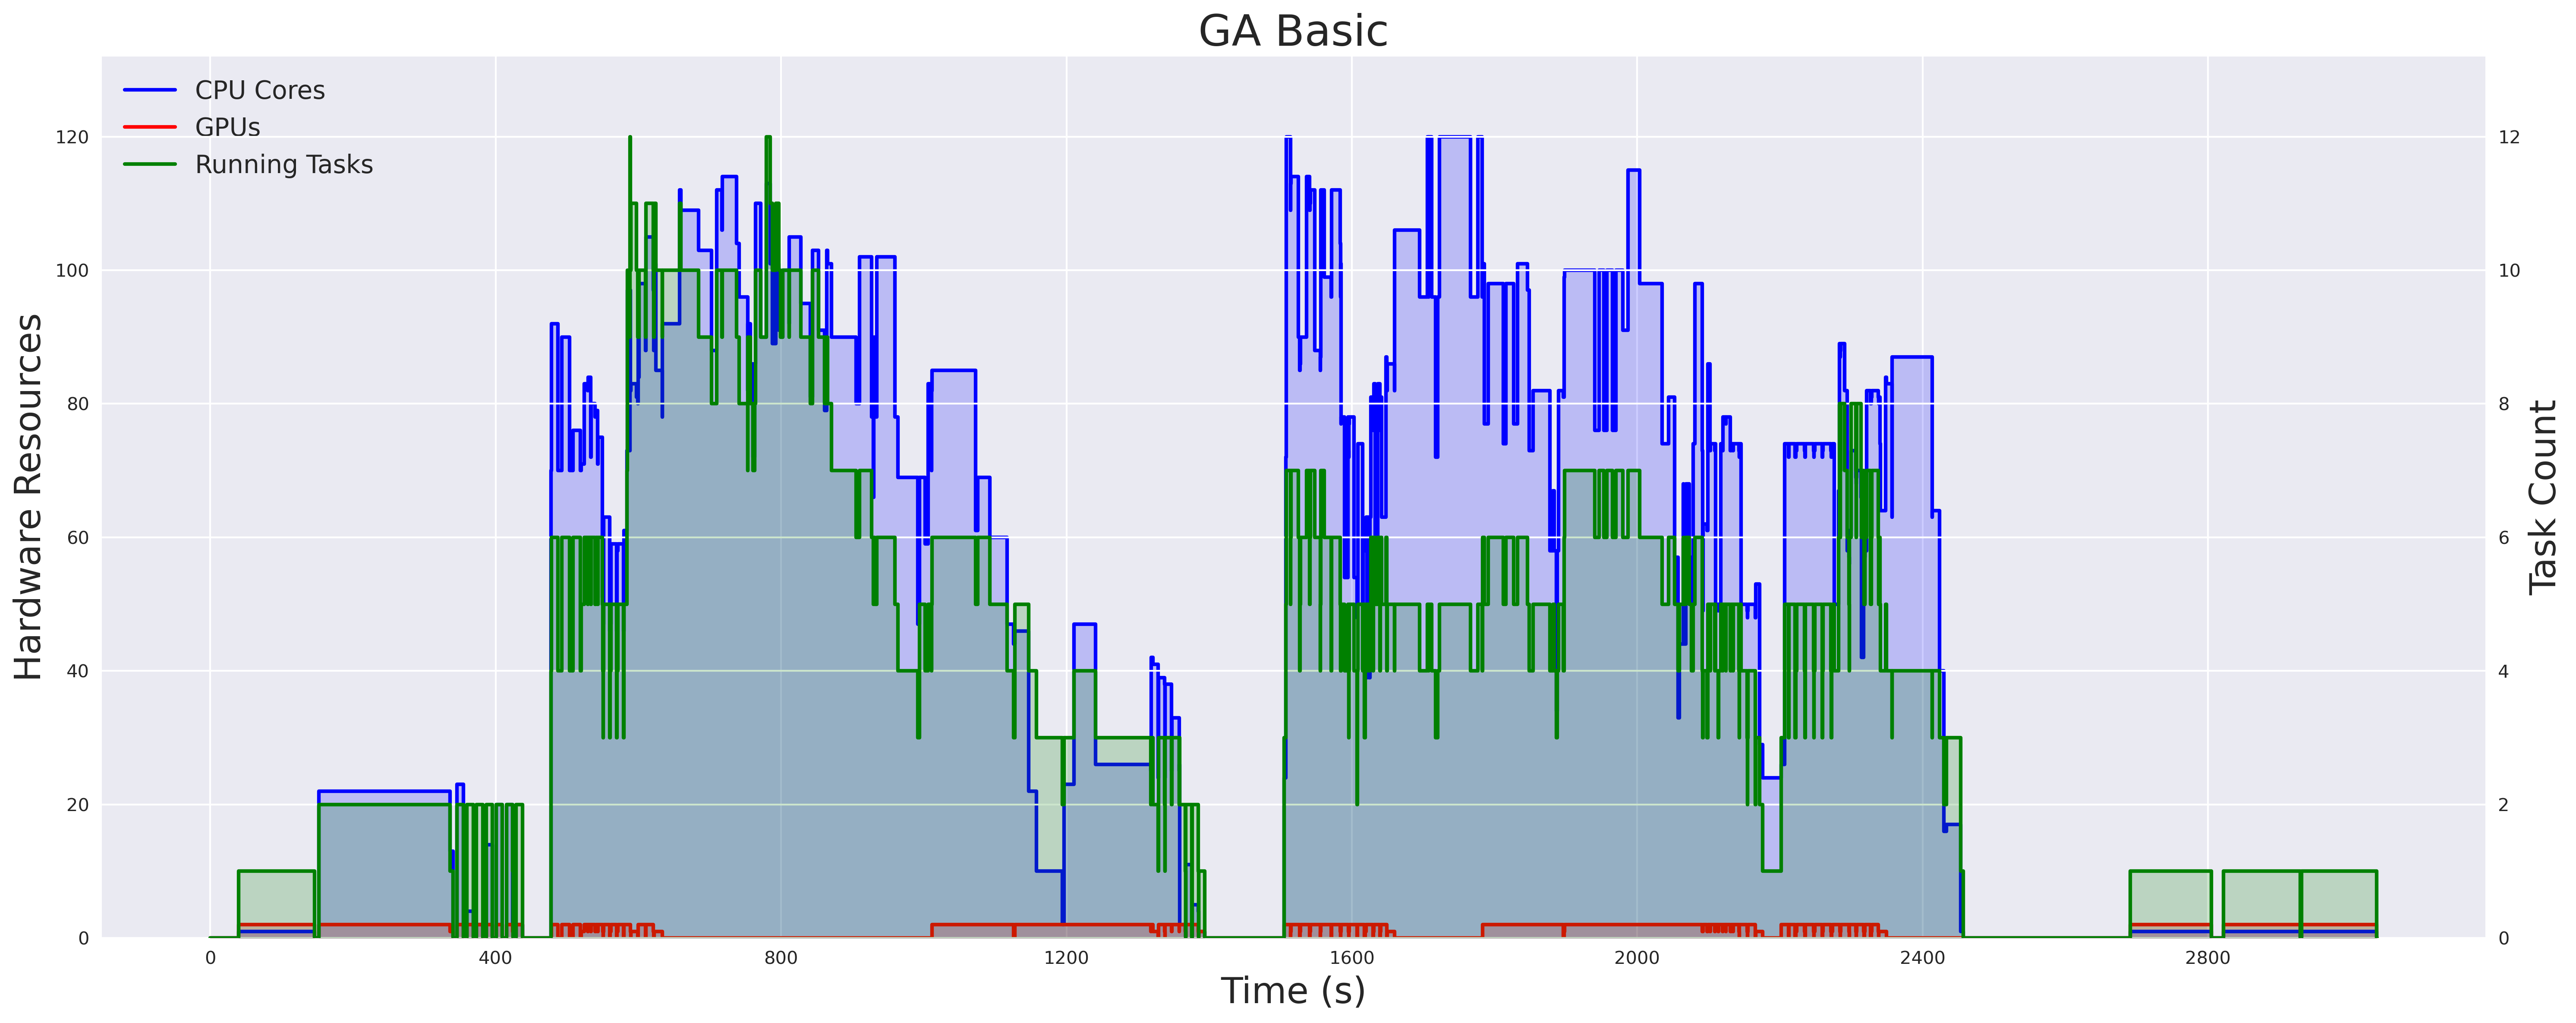

In [53]:
results = load_results(Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250228_082313_ga_basic/dft-md-25Feb28-082342-278820'), task_type)
plot_total_resource_usage(results, task_color,title='GA Basic')

In [ ]:
results = load_results(Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250228_082313_ga_basic/dft-md-25Feb28-082342-278820'), task_type)
plot_total_resource_usage(results, task_color,title='GA Basic')

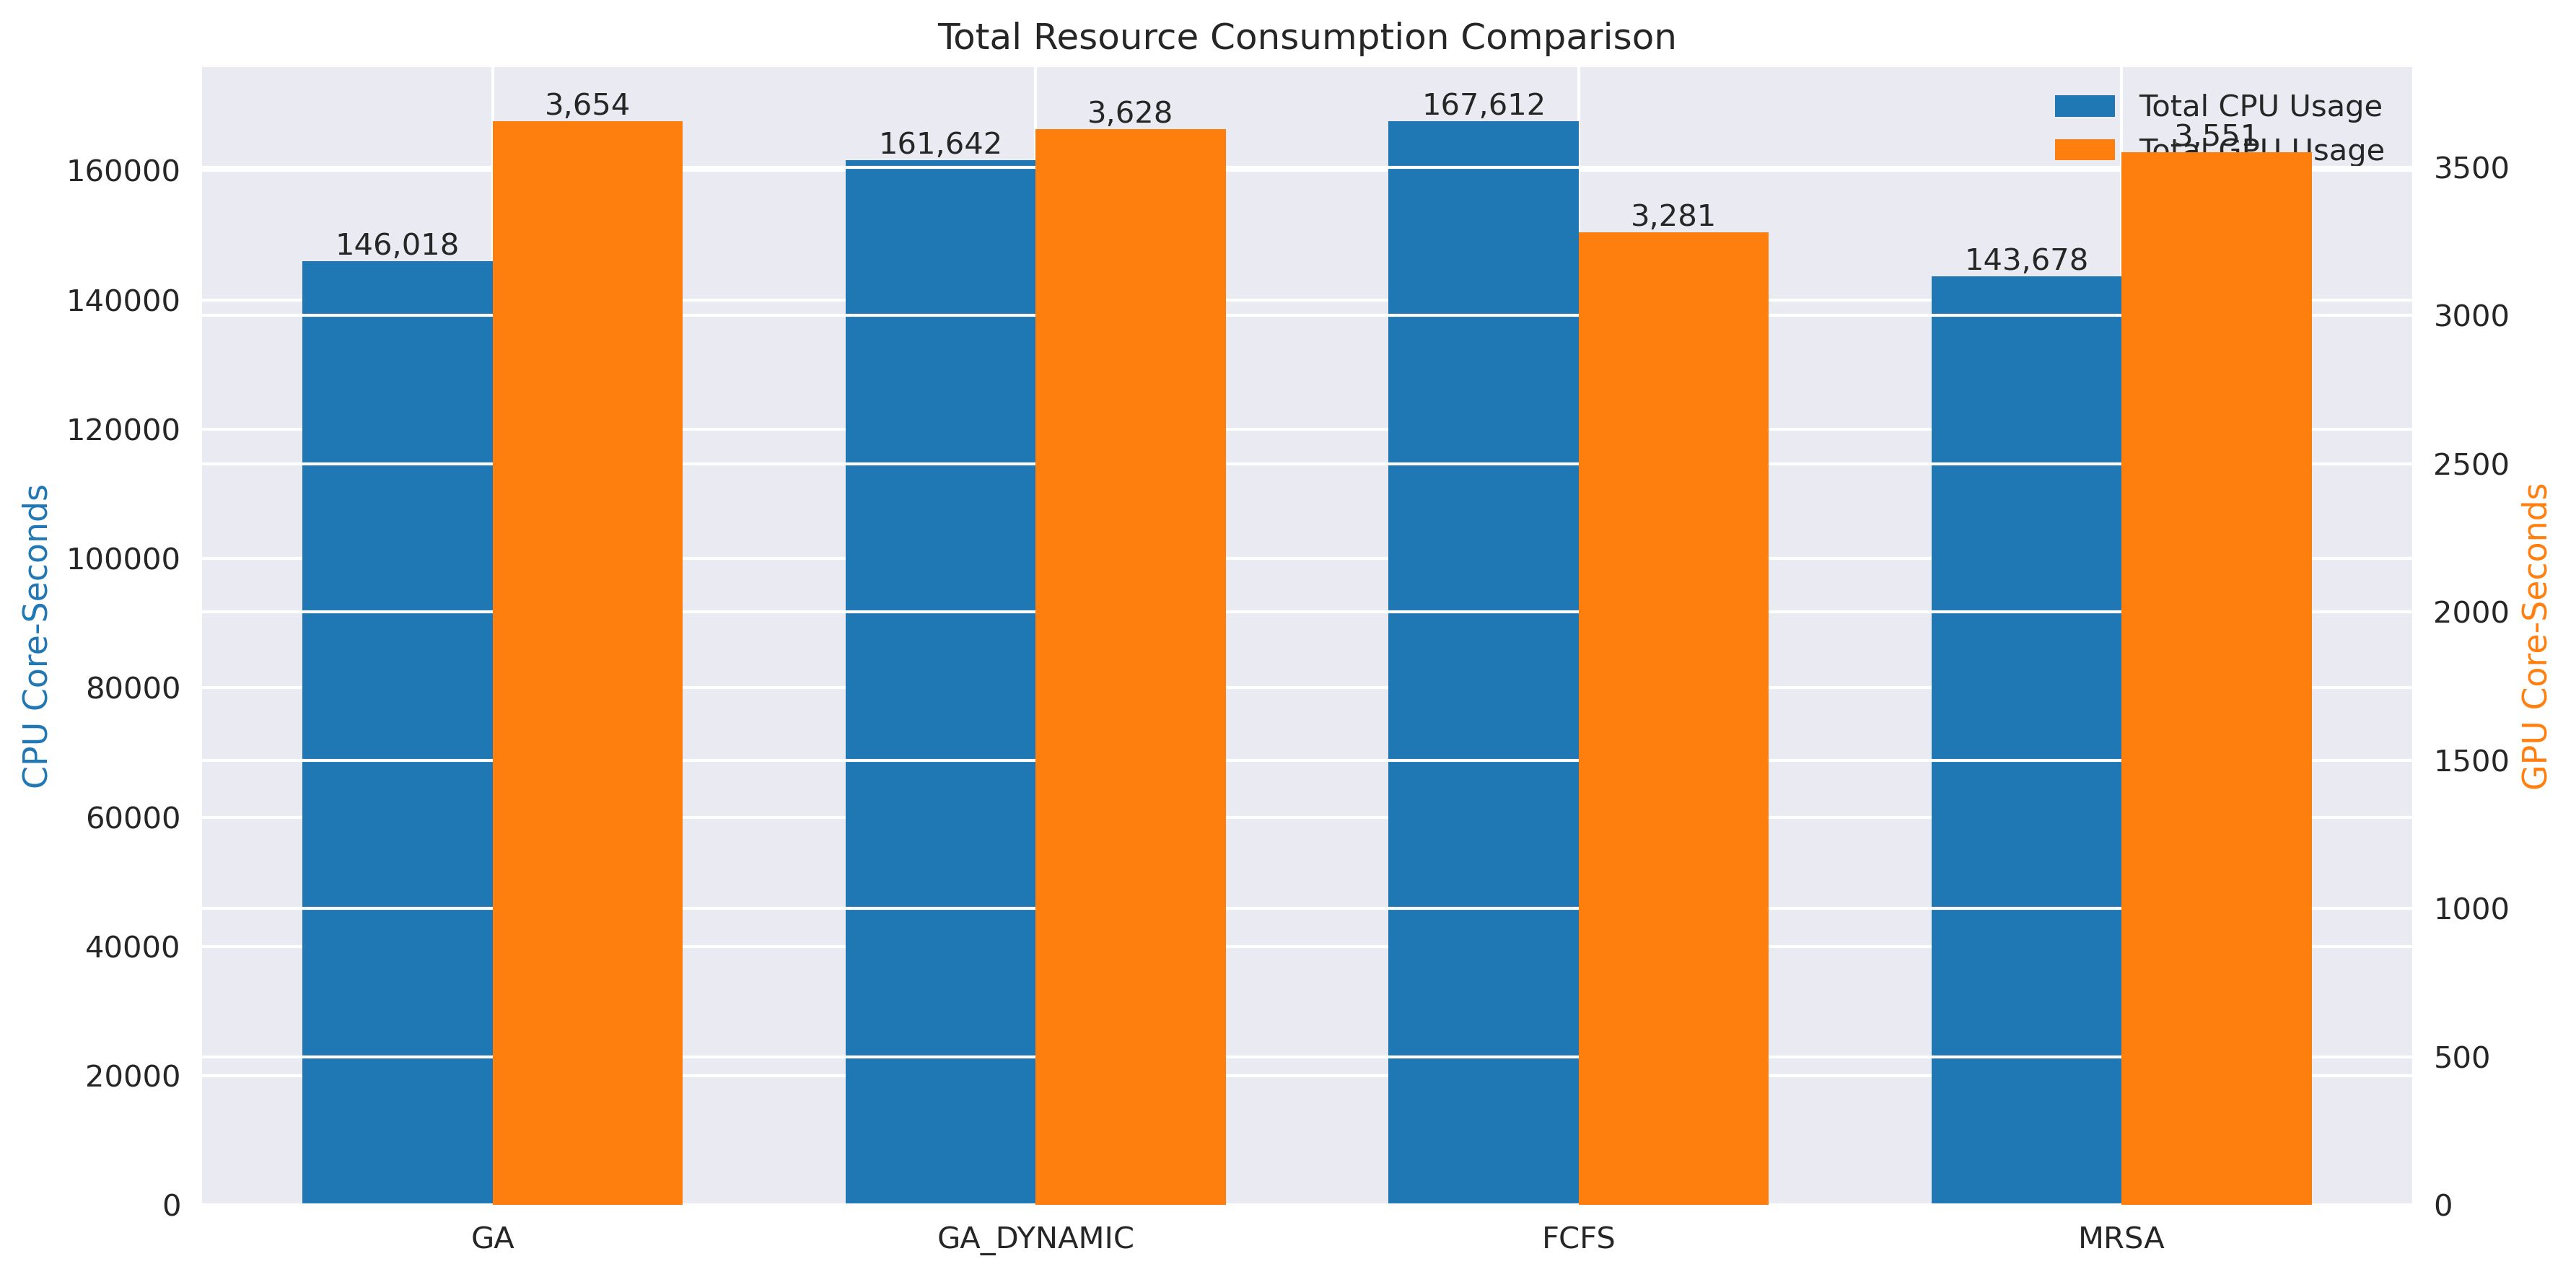

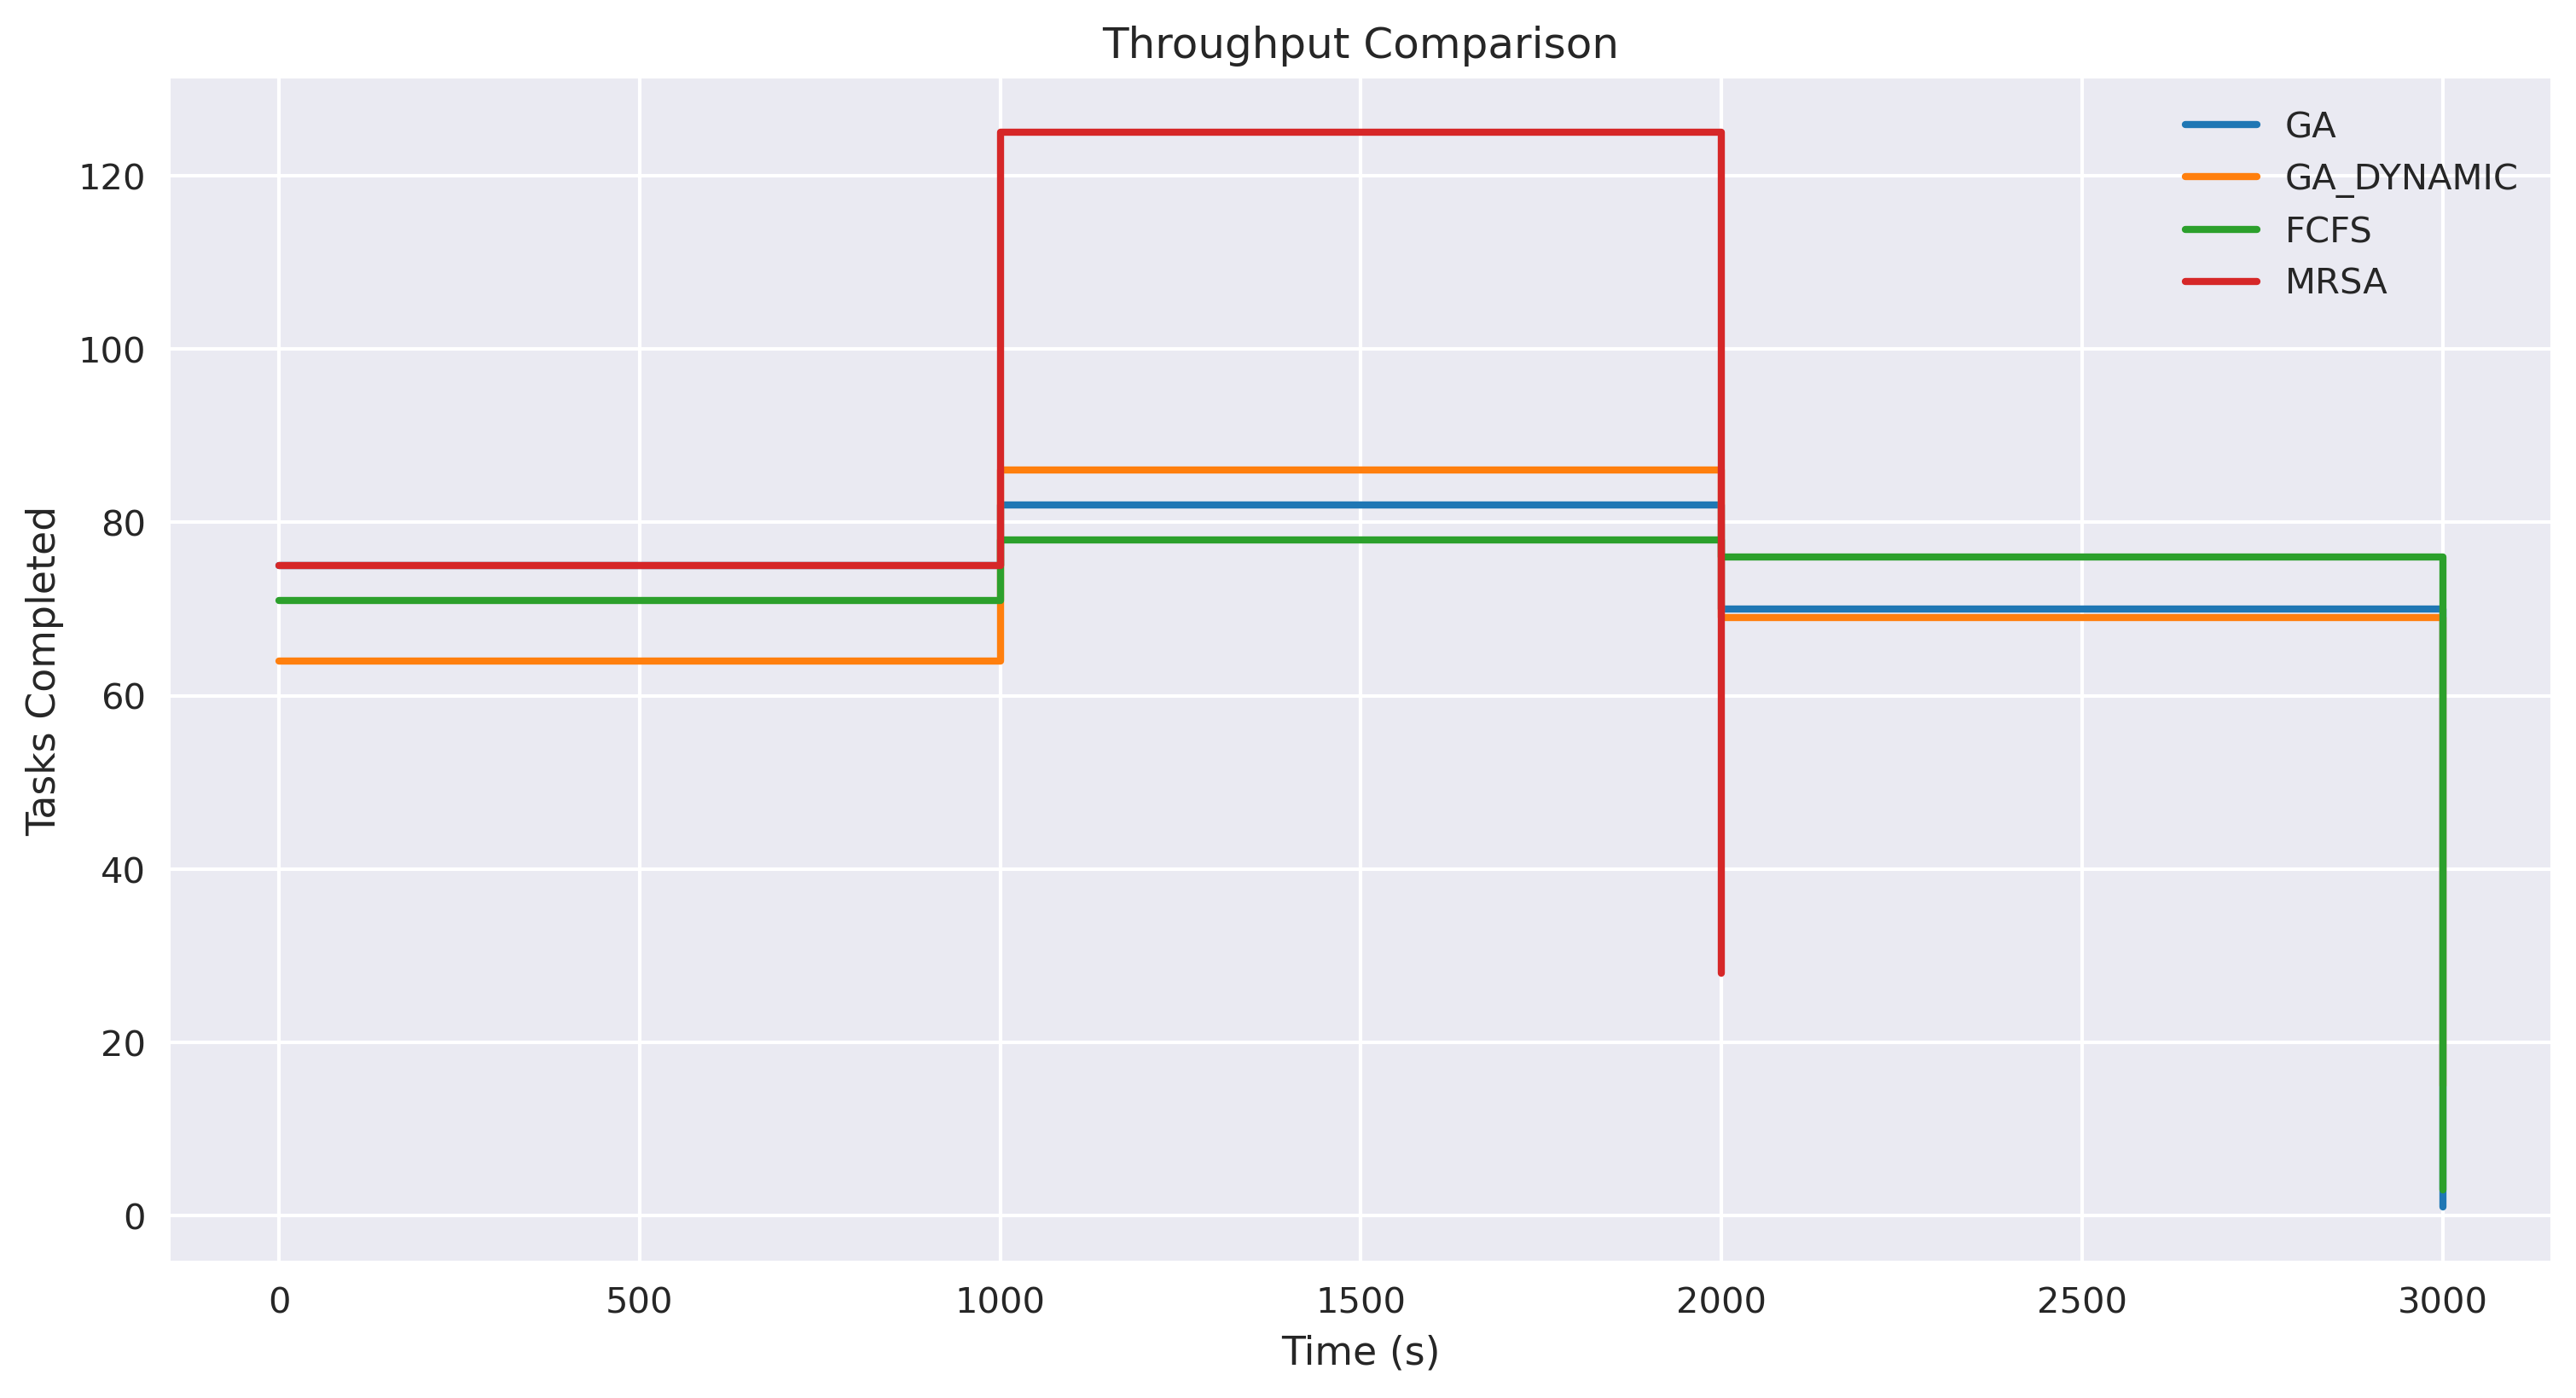

In [ ]:


import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# 先定义数据加载函数
def load_all_stats(scheduler_paths):
    """加载所有调度器的统计数据"""
    all_stats = {}
    
    for name, path in scheduler_paths.items():
        # 加载原始数据
        results = load_results(path, task_type)
        
        # 计算统计数据
        node_stats = calculate_node_stats(results, path.parent.parent / "resources.ini")
        task_stats = calculate_task_stats(results)
        throughput = calculate_throughput(results)
        
        all_stats[name] = {
            'node': node_stats,
            'task': task_stats,
            'throughput': throughput,
            'wct': get_wct(results)  # 获取工作流总时间
        }
    
    return all_stats

# 加载所有数据（示例）
all_stats = load_all_stats(scheduler_paths)

# 设置可视化样式
plt.style.use('seaborn')
scheduler_colors = {
    'ga': '#1f77b4',
    'ga_dynamic': '#ff7f0e',
    'fcfs': '#2ca02c',
    'mrsa': '#d62728'
}

# 1. 节点资源利用率对比
# def plot_node_utilization(all_stats):
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

#     # CPU利用率对比（所有节点）
#     cpu_data = {}
#     gpu_data = {}
#     for scheduler, stats in all_stats.items():
#         # 合并所有CPU节点的利用率
#         cpu_util = np.mean([n['cpu_utilization'] for n in stats['node'].values()])
        
#         # 合并所有GPU节点的利用率（gpu_utilization > 0 的节点）
#         gpu_nodes = [n for n in stats['node'].values() if n['gpu_utilization'] > 0]
#         gpu_util = np.mean([n['gpu_utilization'] for n in gpu_nodes]) if gpu_nodes else 0
        
#         cpu_data[scheduler] = cpu_util * 100
#         gpu_data[scheduler] = gpu_util * 100

#     # 绘制柱状图
#     width = 0.35
#     x = np.arange(len(cpu_data))
    
#     ax1.bar(x - width/2, cpu_data.values(), width, label='CPU', color='#4c72b0')
#     ax1.bar(x + width/2, gpu_data.values(), width, label='GPU', color='#55a868')
#     ax1.set_xticks(x)
#     ax1.set_xticklabels([s.upper() for s in cpu_data.keys()])
#     ax1.set_ylabel('Utilization (%)')
#     ax1.set_title('Average Resource Utilization')
#     ax1.legend()

#     # 资源配置分布玫瑰图
#     node_types = defaultdict(int)
#     for stats in all_stats.values():
#         for node in stats['node'].values():
#             key = f"{node.get('gpu_utilization',0)*100:.0f}% GPU\n{node.get('cpu_utilization',0)*100:.0f}% CPU"
#             node_types[key] += 1

#     ax2.pie(node_types.values(), labels=node_types.keys(),
#            autopct='%1.1f%%', startangle=90,
#            colors=plt.cm.Paired(np.linspace(0, 1, len(node_types))),
#            wedgeprops=dict(width=0.5))
#     ax2.set_title('Resource Utilization Distribution')

#     plt.tight_layout()
def plot_total_utilization(all_stats, resources_path):
    # 加载节点资源配置
    node_config = parse_resources_ini(resources_path)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 准备数据
    schedulers = list(all_stats.keys())
    cpu_utils = []
    gpu_utils = []
    
    for scheduler, stats in all_stats.items():
        total_cpu_util = 0
        total_gpu_util = 0
        
        # 计算加权平均值
        for node_name, node_stats in stats['node'].items():
            # 获取节点配置
            config = node_config.get(node_name, {'cpus': 0, 'gpus': 0})
            
            # CPU加权计算
            cpu_weight = config['cpus']
            total_cpu_util += node_stats['cpu_utilization'] * cpu_weight
            
            # GPU加权计算
            if config['gpus'] > 0:
                gpu_weight = config['gpus']
                total_gpu_util += node_stats['gpu_utilization'] * gpu_weight
        
        # 计算总权重
        total_cpu_cores = sum(n['cpus'] for n in node_config.values())
        total_gpu_units = sum(n['gpus'] for n in node_config.values())
        
        cpu_utils.append(total_cpu_util / total_cpu_cores * 100 if total_cpu_cores >0 else 0)
        gpu_utils.append(total_gpu_util / total_gpu_units * 100 if total_gpu_units >0 else 0)

    # 绘制柱状图
    x = np.arange(len(schedulers))
    width = 0.35
    
    rects1 = ax.bar(x - width/2, cpu_utils, width, label='CPU Utilization', color='#1f77b4')
    rects2 = ax.bar(x + width/2, gpu_utils, width, label='GPU Utilization', color='#ff7f0e')
    
    # 添加标签和样式
    ax.set_ylabel('Utilization Rate (%)')
    ax.set_title('Total Resource Utilization by Scheduler')
    ax.set_xticks(x)
    ax.set_xticklabels([s.upper() for s in schedulers])
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    
    # 添加数据标签
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width()/2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')
    
    autolabel(rects1)
    autolabel(rects2)
    
    plt.ylim(0, max(max(cpu_utils), max(gpu_utils)) * 1.2)
    plt.tight_layout()

# 使用示例（需要传入resources.ini路径）
# plot_total_utilization(all_stats, Path('/path/to/resources.ini'))

# 2. 任务资源消耗对比
def plot_resource_usage(all_stats):
    """统一呈现CPU/GPU总利用率"""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 准备数据
    schedulers = list(all_stats.keys())
    cpu_totals = []
    gpu_totals = []
    
    for scheduler in schedulers:
        # 计算总CPU利用率（所有任务类型的总和）
        cpu_total = sum(
            t_stats['total_cpu_area'] 
            for t_stats in all_stats[scheduler]['task'].values()
        )
        cpu_totals.append(cpu_total)
        
        # 计算总GPU利用率
        gpu_total = sum(
            t_stats['total_gpu_area'] 
            for t_stats in all_stats[scheduler]['task'].values()
        )
        gpu_totals.append(gpu_total)

    # 标准化处理（可选）
    max_cpu = max(cpu_totals)
    max_gpu = max(gpu_totals)
    cpu_norm = [x/max_cpu*100 for x in cpu_totals]
    gpu_norm = [x/max_gpu*100 for x in gpu_totals] if max_gpu > 0 else [0]*len(gpu_totals)

    # 绘制双轴柱状图
    ax1 = ax
    ax2 = ax1.twinx()
    
    width = 0.35
    x = np.arange(len(schedulers))
    
    # CPU柱状图
    bars1 = ax1.bar(x - width/2, cpu_totals, width, 
                   color='#1f77b4', label='Total CPU Usage')
    # GPU柱状图
    bars2 = ax2.bar(x + width/2, gpu_totals, width, 
                   color='#ff7f0e', label='Total GPU Usage')

    # 标签和样式设置
    ax1.set_ylabel('CPU Core-Seconds', color='#1f77b4')
    ax2.set_ylabel('GPU Core-Seconds', color='#ff7f0e')
    ax1.set_xticks(x)
    ax1.set_xticklabels([s.upper() for s in schedulers])
    ax1.set_title('Total Resource Consumption Comparison')
    
    # 添加数据标签
    def add_labels(bars, ax):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:,.0f}',
                    ha='center', va='bottom')
    
    add_labels(bars1, ax1)
    if max_gpu > 0:
        add_labels(bars2, ax2)

    # 合并图例
    lines = [bars1, bars2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')

    plt.tight_layout()

# 3. 吞吐量对比
def plot_throughput(all_stats):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    max_wct = max(s['wct'] for s in all_stats.values())
    time_bins = np.arange(0, max_wct+1000, 1000)
    
    for scheduler, stats in all_stats.items():
        total_counts = []
        for window in stats['throughput']:
            total_counts.append(sum(window['counts'].values()))
        
        # 对齐时间轴
        x = [w['window'][0] for w in stats['throughput']]
        ax.step(x, total_counts, where='post', 
               label=scheduler.upper(), 
               linewidth=2,
               color=scheduler_colors[scheduler])
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Tasks Completed')
    ax.set_title('Throughput Comparison')
    ax.legend()
    ax.grid(True)

# 执行所有绘图
# plot_node_utilization(all_stats)
plot_resource_usage(all_stats)
plot_throughput(all_stats)
plt.show()

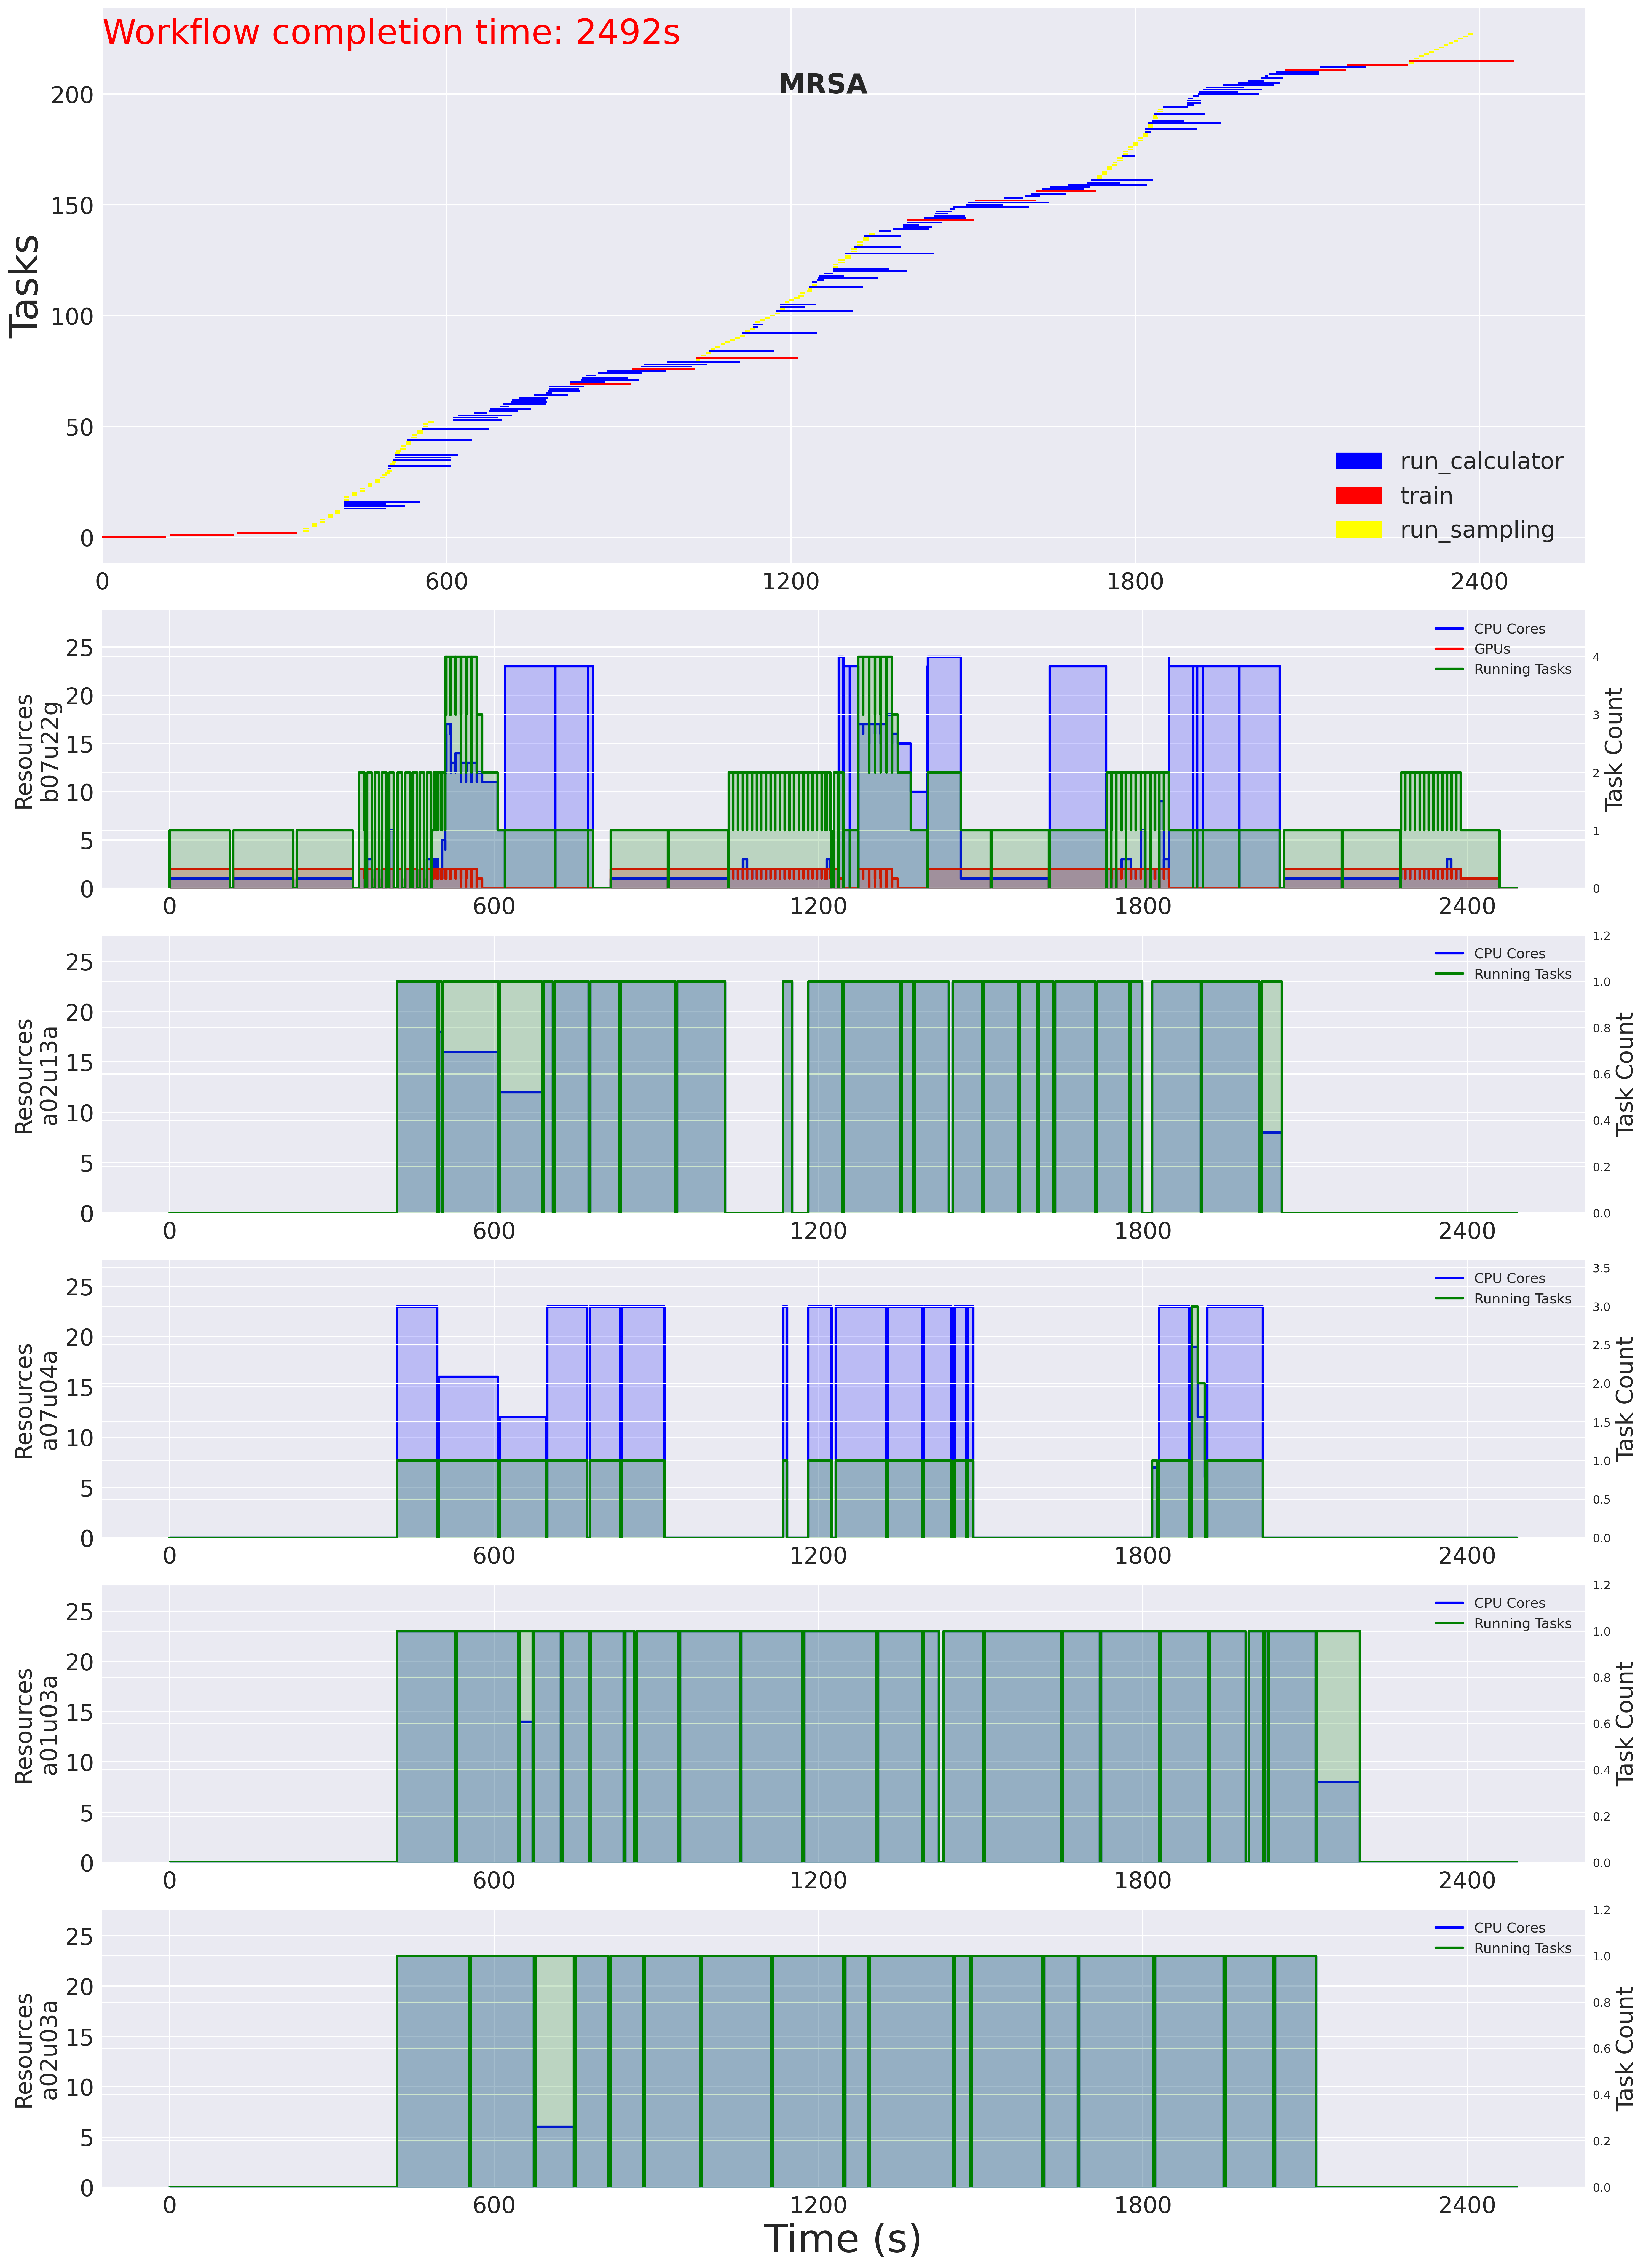

In [36]:
# mrsa
mrsa_test_path = Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250313_192939_mrsa_basic/dft-md-25Mar13-193022-7ce712')
results = load_results(mrsa_test_path, task_type=task_type)
time_line_graph(results=results, task_color=task_color, title="MRSA")

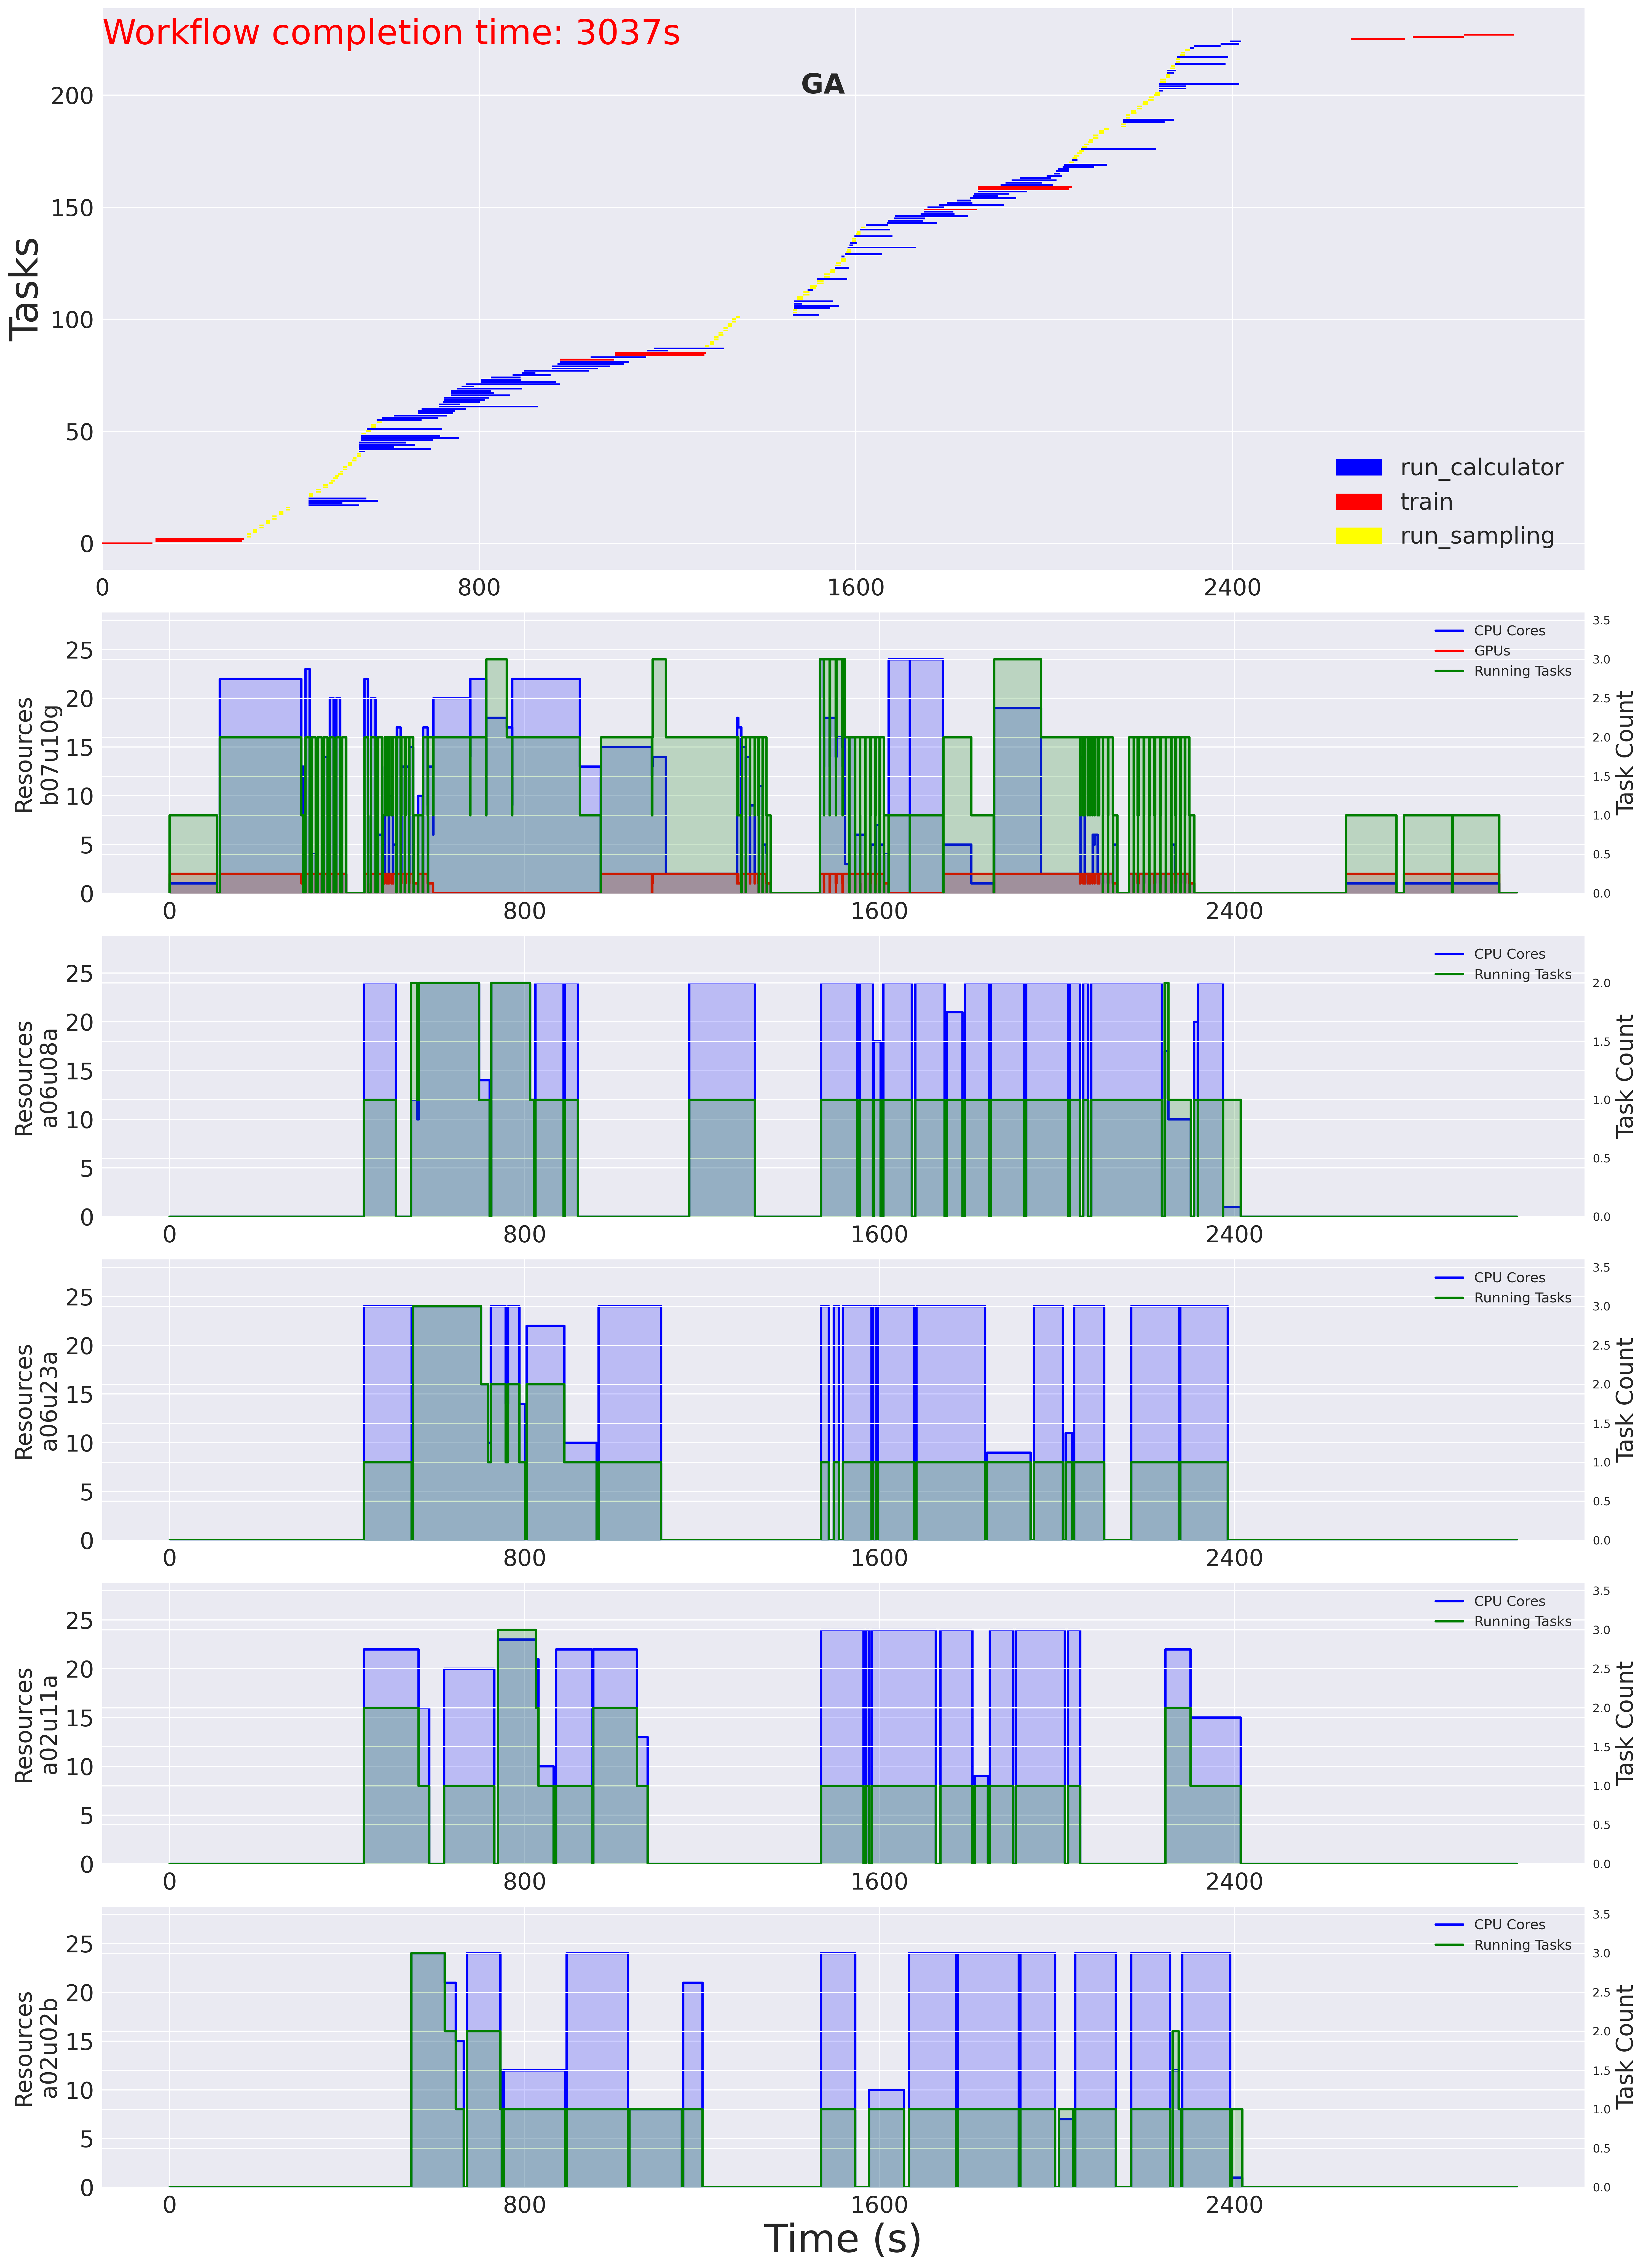

In [40]:
mrsa_test_path = Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250228_082313_ga_basic/dft-md-25Feb28-082342-278820')
results = load_results(mrsa_test_path, task_type=task_type)
time_line_graph(results=results, task_color=task_color, title="GA")

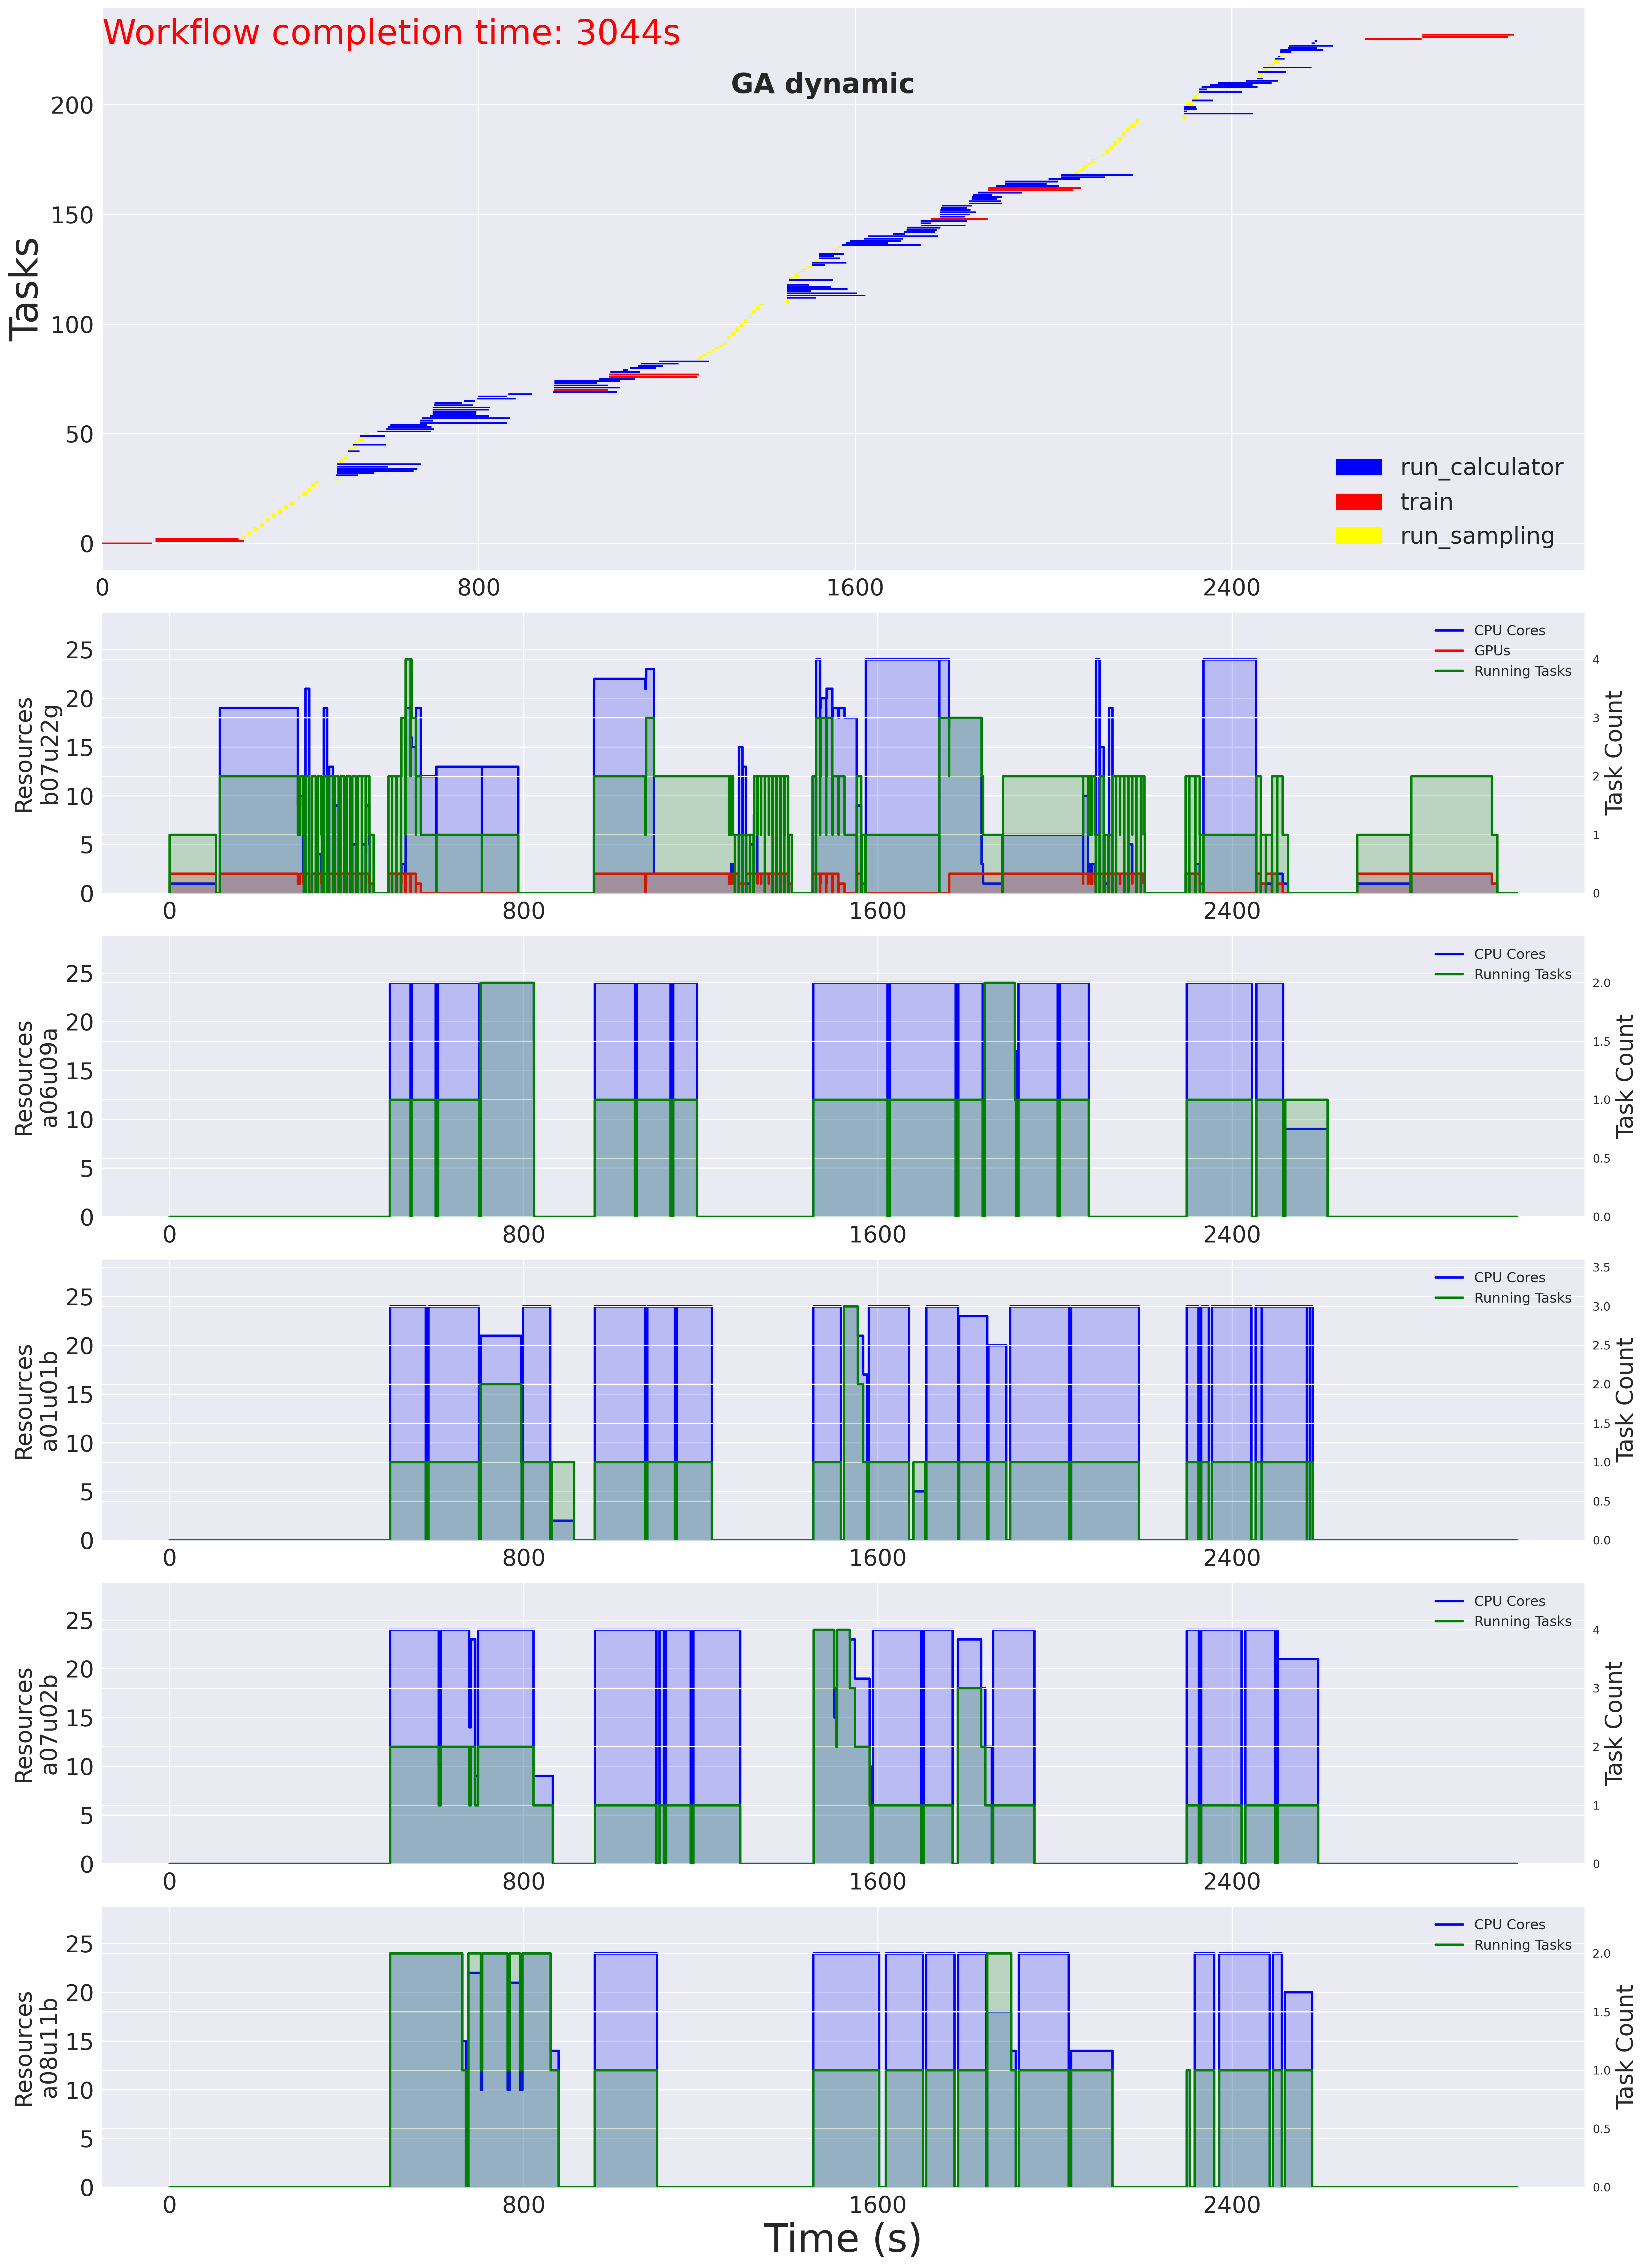

In [43]:
mrsa_test_path = Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/20250314_013806/dft-md-25Mar14-013849-2d9c22')
results = load_results(mrsa_test_path, task_type=task_type)
time_line_graph(results=results, task_color=task_color, title="GA dynamic")

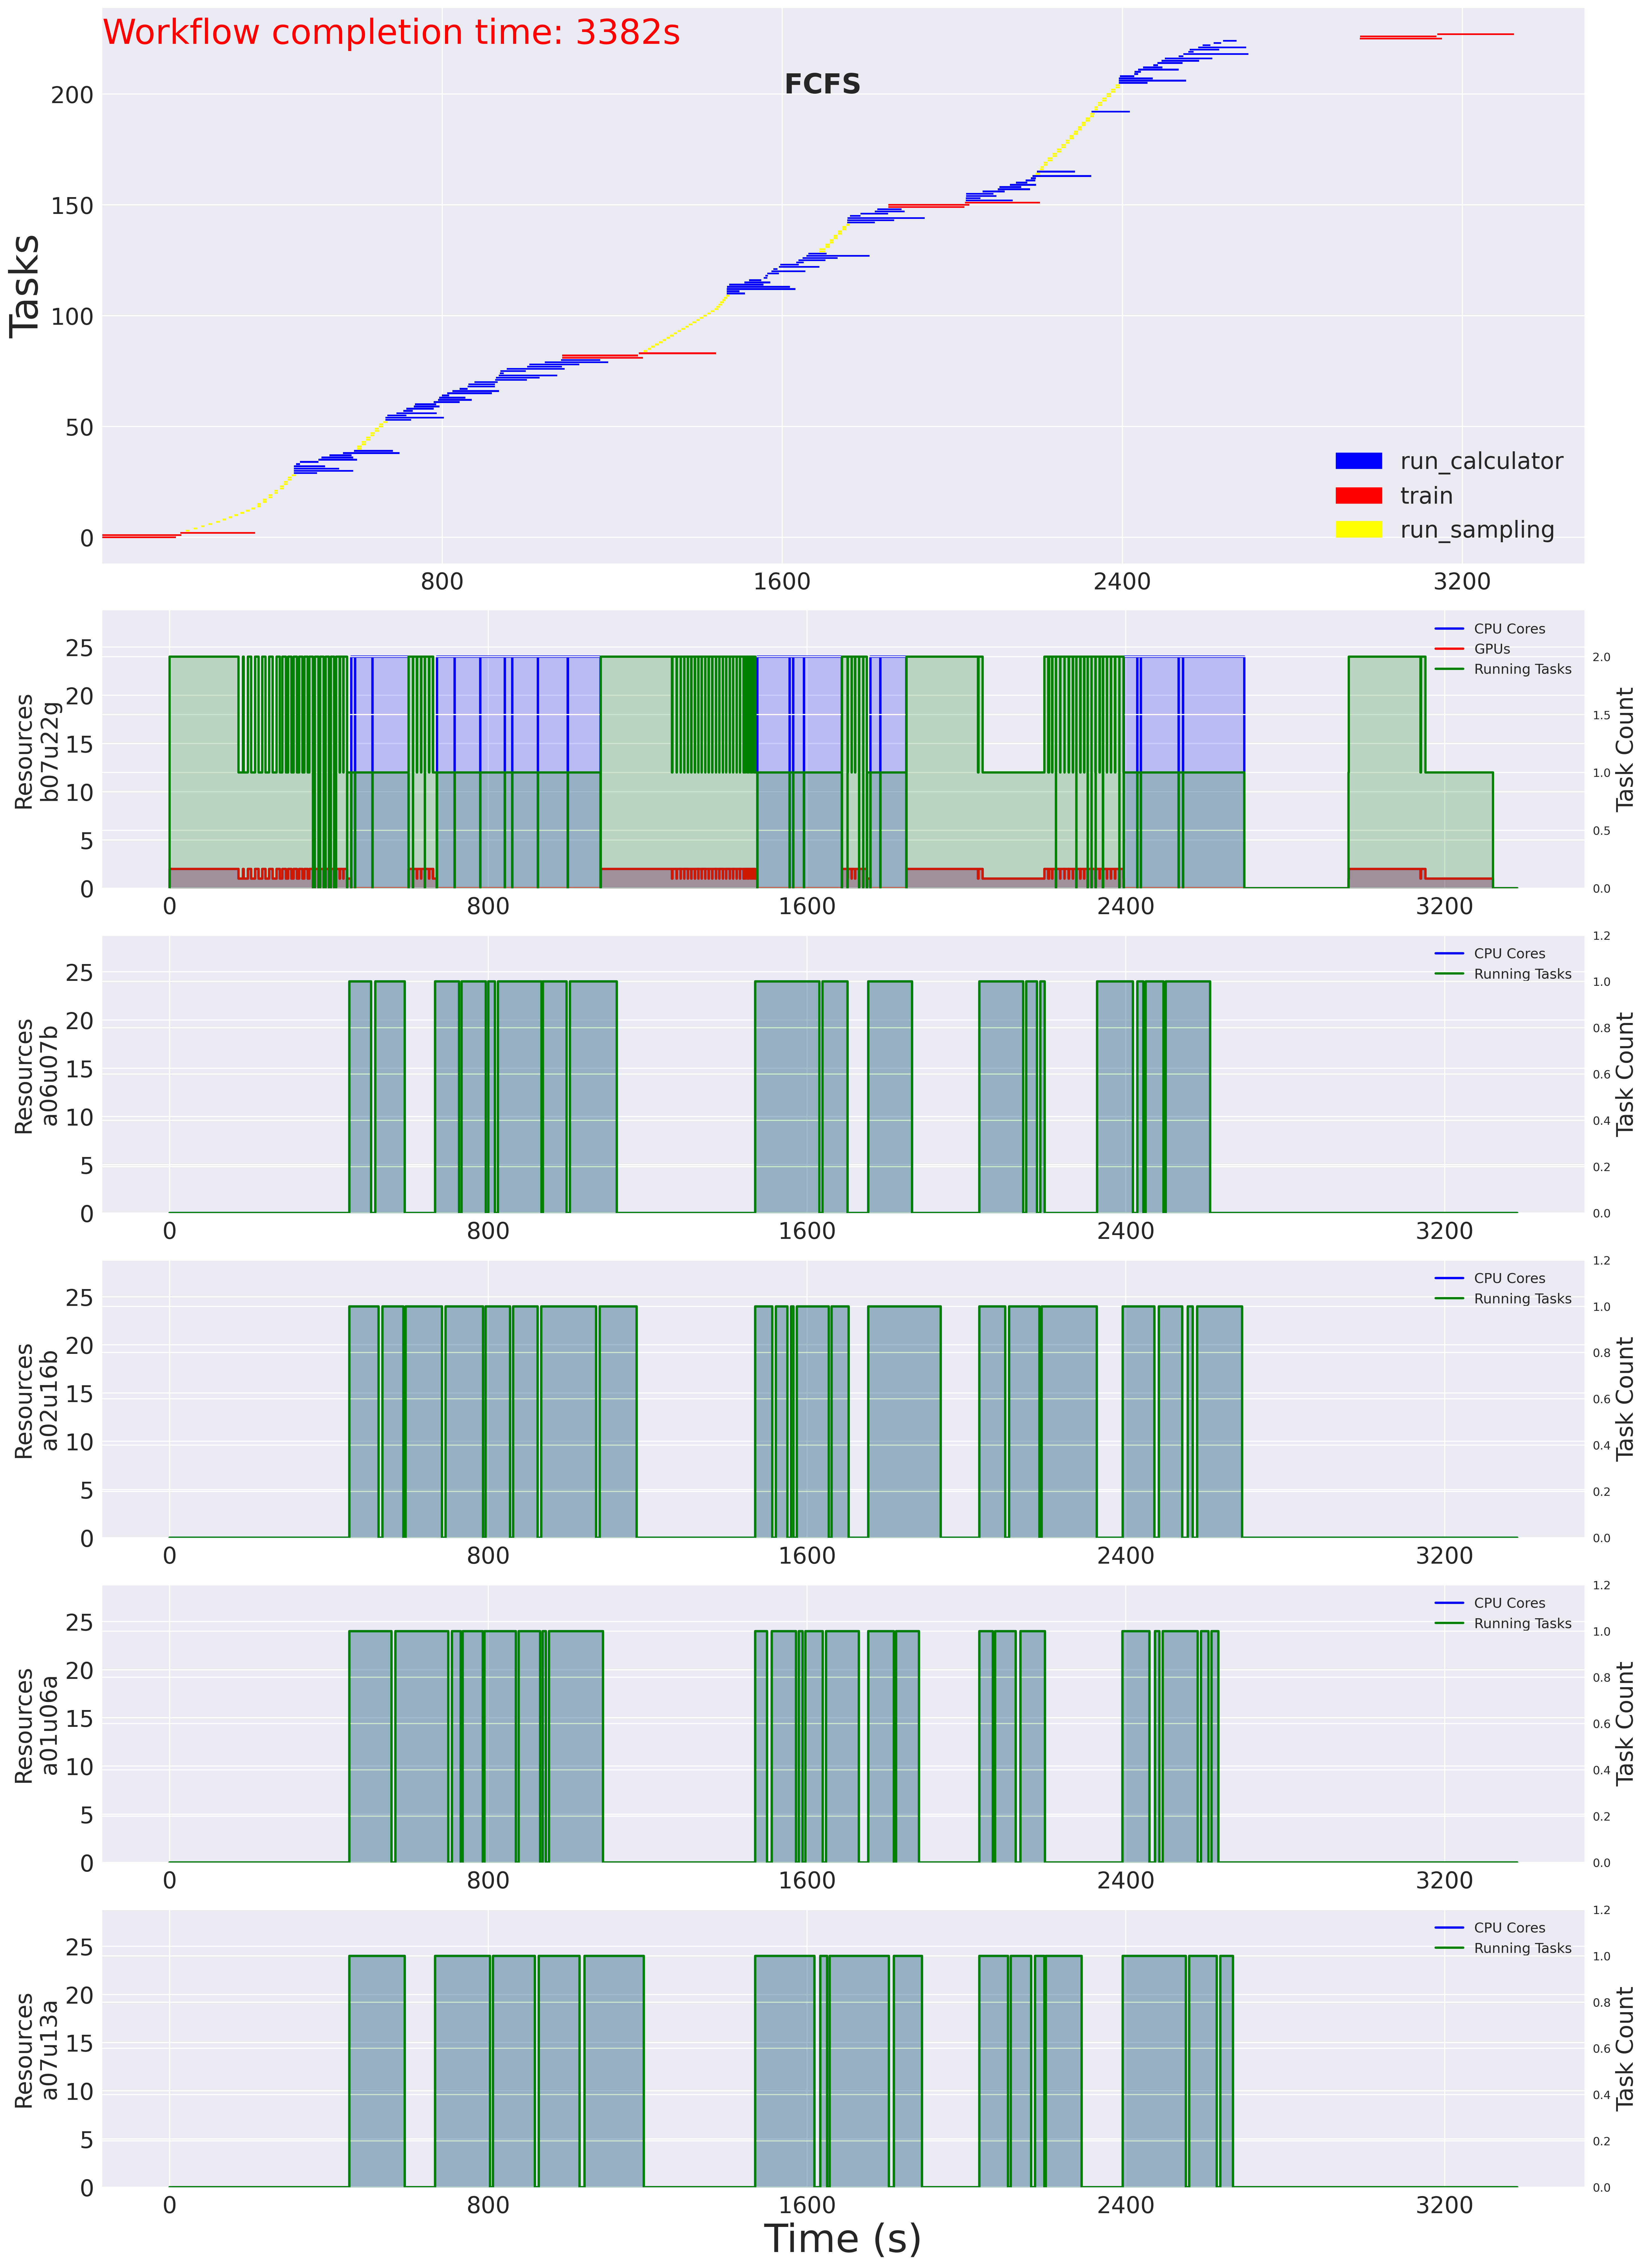

In [44]:
mrsa_test_path = Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250303_202640_fcfs_24core/dft-md-25Mar03-202722-6b6f06')
results = load_results(mrsa_test_path, task_type=task_type)
time_line_graph(results=results, task_color=task_color, title="FCFS")